In [149]:
import os
import re
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
import pandas as pd
import ast
import torch
import pickle
import numpy as np


## Training curves

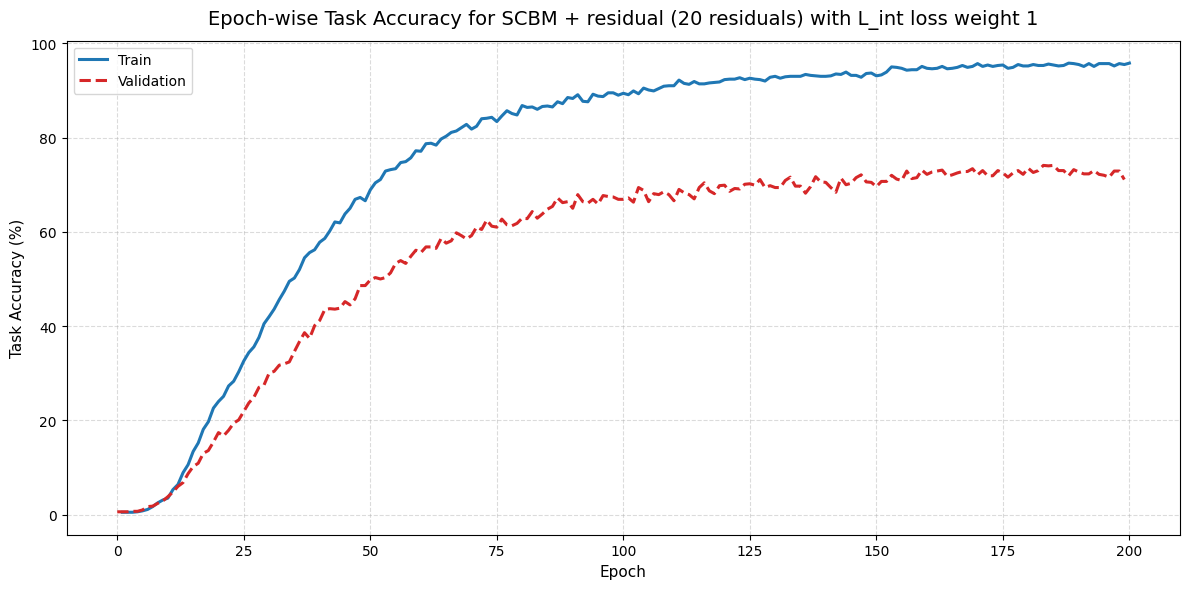

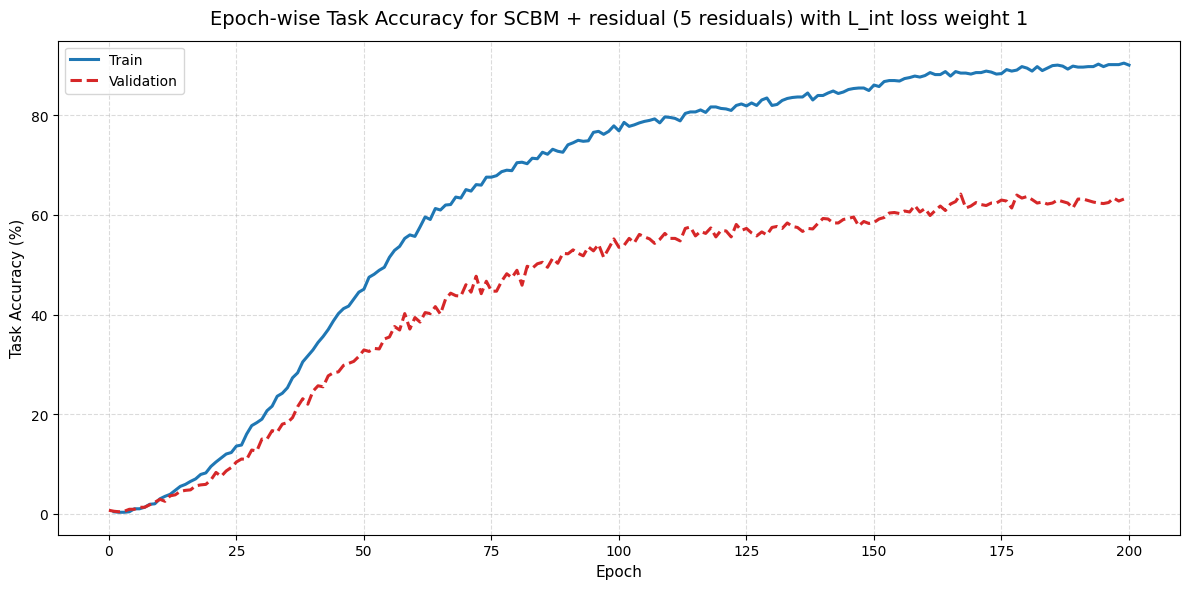

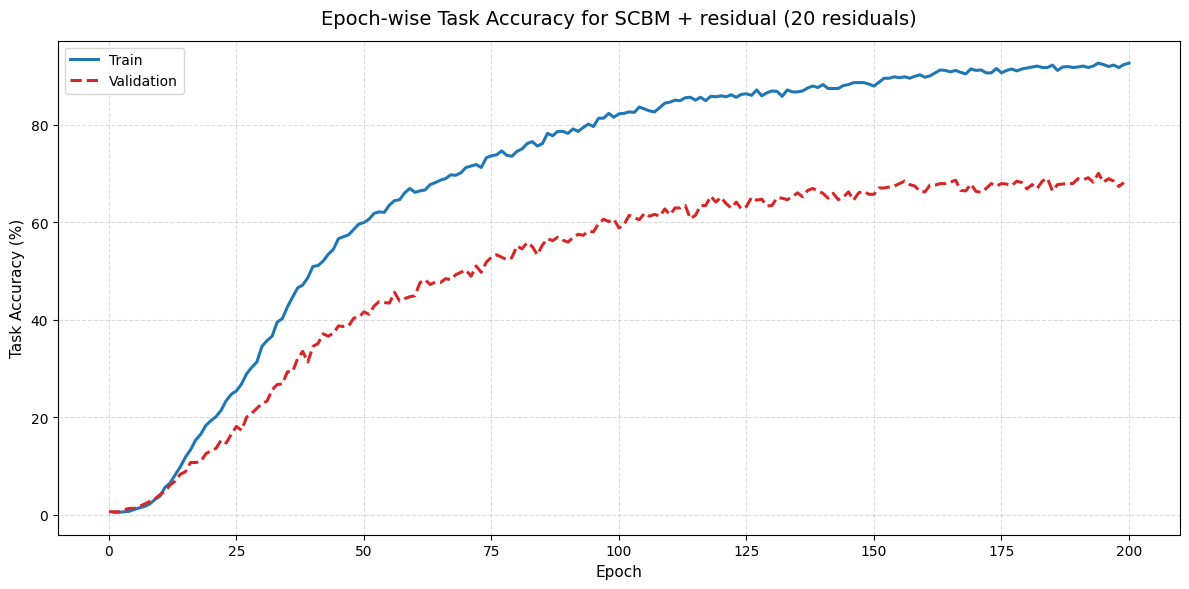

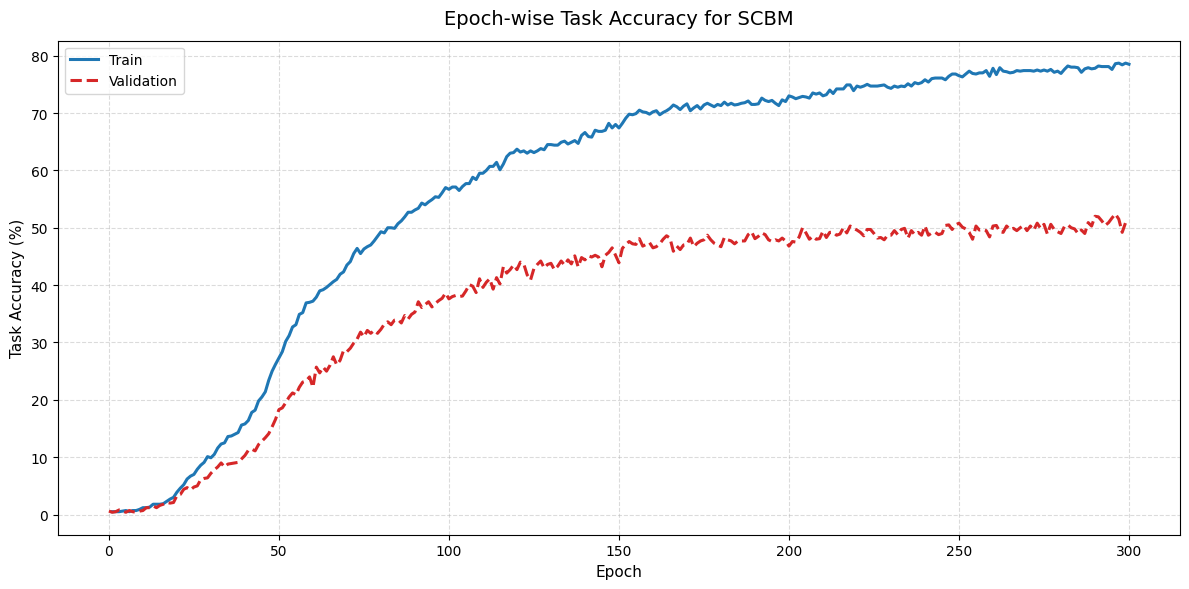

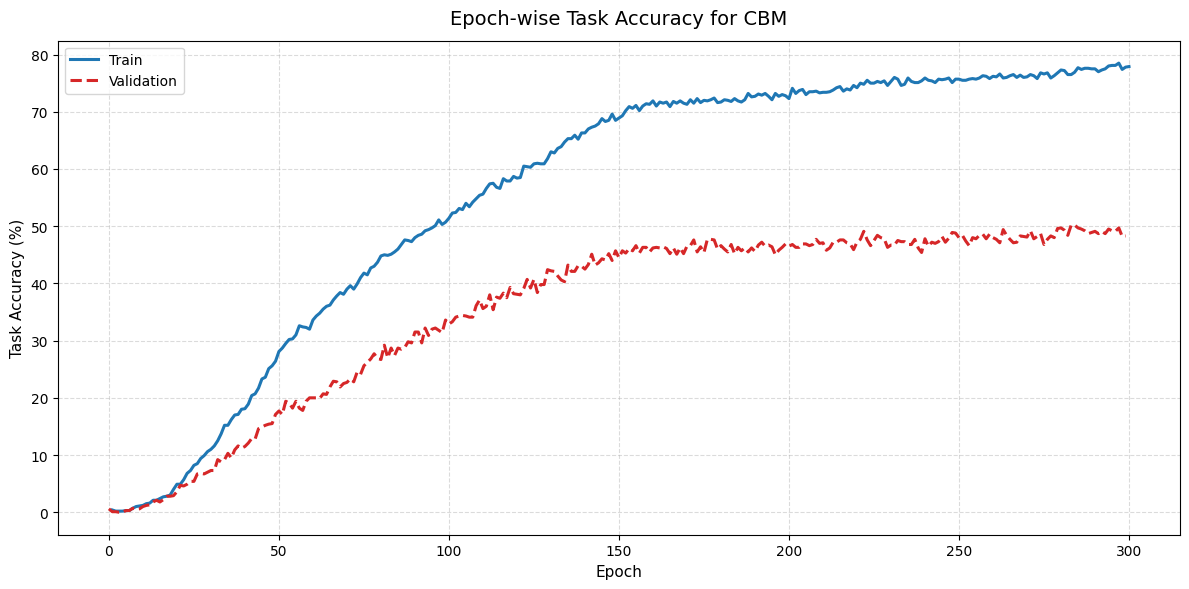

In [150]:
def extract_epoch_accuracies(full_model_path, split="Train"):
    epoch_accuracies = []
    with open(os.path.join(full_model_path, "log.txt"), "r") as f:
        lines = f.readlines()
        for line in lines:
            if "Epoch" in line and "y_accuracy" in line and "c_accuracy" in line and split in line:
                epoch_num = re.findall(r"Epoch\s*(\d+)", line)[0]
                y_accuracy = re.findall(r"y_accuracy:\s*([0-9.]+)", line)[0]
                c_accuracy = re.findall(r"c_accuracy:\s*([0-9.]+)", line)[0]
                epoch_accuracies.append((int(epoch_num), float(y_accuracy) * 100, float(c_accuracy) * 100))
    return epoch_accuracies

scbm_model_dir = os.path.join("experiments", "scbm", "TravelingBirds")
scbm_res_model_dir = os.path.join("experiments", "scbm_residual", "TravelingBirds")
cbm_model_dir = os.path.join("experiments", "cbm", "TravelingBirds")

model_dirs_titles = [(scbm_res_model_dir,
                      "Mateo_025_fixed_emp_perc_residuals_20_L_int_extension_loss_weight_1_2026-08-11_12-01-55_9dbed",
                      "SCBM + residual (20 residuals) with L_int loss weight 1"),
                    (scbm_res_model_dir, 
                      "Mateo_025_fixed_emp_perc_residuals_5_L_int_extension_loss_weight_1_2026-08-10_17-06-05_57592", 
                      "SCBM + residual (5 residuals) with L_int loss weight 1"),
                     (scbm_res_model_dir,
                      "Mateo_025_fixed_residuals_20_2026-08-10_17-06-05_7679e",
                      "SCBM + residual (20 residuals)"),
                     (scbm_model_dir,
                      "Mateo_025_2026-08-10_17-06-22_5b4d7",
                      "SCBM"),
                     (cbm_model_dir,
                      "Mateo_025_2026-08-10_17-07-25_84e08",
                      "CBM")]


for root_model_dir, model_name, title in model_dirs_titles:
    full_model_path = os.path.join(root_model_dir, model_name)
    train_accuracies = extract_epoch_accuracies(full_model_path, split="Train")
    val_accuracies = extract_epoch_accuracies(full_model_path, split="Validation")
    fig, ax = plt.subplots(figsize=(12, 6))
    ax.plot(
        [epoch[0] for epoch in train_accuracies],
        [epoch[1] for epoch in train_accuracies],
        label="Train",
        color="#1f77b4",
        linewidth=2.2,
        markersize=6,
    )
    ax.plot(
        [epoch[0] for epoch in val_accuracies],
        [epoch[1] for epoch in val_accuracies],
        label="Validation",
        color="#d62728",
        linestyle="--",
        linewidth=2.2,
        markersize=6,
    )
    ax.set_title(f"Epoch-wise Task Accuracy for {title}", fontsize=14, pad=12)
    ax.set_xlabel("Epoch", fontsize=11)
    ax.set_ylabel("Task Accuracy (%)", fontsize=11)
    ax.grid(True, which="major", linestyle="--", alpha=0.45)
    ax.legend(loc="upper left")
    fig.tight_layout()
    plt.show()
    


## Interventions 

In [151]:
def extract_info_from_intervention_log(model_dir, model_type="scbm", dataset="TravelingBirds", return_c_auroc=False, return_auroc=False, intervention_on_val=False):
    experiment_path = os.path.join("experiments", model_type, dataset)
    concepts_intervened_list = []
    y_accuracies_list = []
    c_accuracies_list = []
    y_auroc_list = []
    c_auroc_list = []
    if intervention_on_val:
        log_txt_path = os.path.join(experiment_path, model_dir, "intervention_log_val.txt")
    else:
        log_txt_path = os.path.join(experiment_path, model_dir, "intervention_log.txt")
    with open(log_txt_path, "r") as f:
        lines = f.readlines()
        for line in lines:
            if "Intervention on" in line and "y_accuracy" in line and "c_accuracy" in line:
                m = re.search(r"Intervention on (\d+) concepts", line)
                if not m:
                    continue
                concepts_intervened = int(m.group(1))

                y_m = re.search(r"y_accuracy:\s*([0-9.]+)", line)
                c_m = re.search(r"c_accuracy:\s*([0-9.]+)", line)
                y_auroc_m = re.search(r"y_AUROC:\s*([0-9.]+)", line)
                c_auroc_m = re.search(r"c_AUROC:\s*([0-9.]+)", line)

                y_accuracy = float(y_m.group(1)) * 100 if y_m else None
                c_accuracy = float(c_m.group(1)) * 100 if c_m else None
                y_auroc = float(y_auroc_m.group(1)) * 100 if y_auroc_m else None
                c_auroc = float(c_auroc_m.group(1)) * 100 if c_auroc_m else None

                concepts_intervened_list.append(concepts_intervened)
                y_accuracies_list.append(y_accuracy)
                c_accuracies_list.append(c_accuracy)
                y_auroc_list.append(y_auroc)
                c_auroc_list.append(c_auroc)
    if return_auroc:
        return concepts_intervened_list, y_accuracies_list, c_accuracies_list, y_auroc_list, c_auroc_list
    if return_c_auroc:
        return concepts_intervened_list, y_accuracies_list, c_accuracies_list, c_auroc_list
    return concepts_intervened_list, y_accuracies_list, c_accuracies_list

In [152]:
def retrieve_acc_from_log(model_dir, linear_model=False):

                with open(os.path.join(model_dir, "log.txt"), "r") as f:
                    lines = f.readlines()
                    test_line = lines[-1]
                    if linear_model:
                        y_accuracy = re.findall(r"Test Accuracy:\s*([0-9.]+)", test_line)[0]
                        c_accuracy = None
                        c_auc = None
                    else:
                        y_accuracy = re.findall(r"y_accuracy:\s*([0-9.]+)", test_line)[0]
                        c_accuracy = re.findall(r"c_accuracy:\s*([0-9.]+)", test_line)[0]
                        c_auc = re.findall(r"c_AUROC:\s*([0-9.]+)", test_line)[0]
                    y_accuracy = float(y_accuracy) * 100
                    if c_accuracy is not None:
                        c_accuracy = float(c_accuracy) * 100
                    return y_accuracy, c_accuracy, c_auc

### OOD incomplete travellingBirds dataset interventions

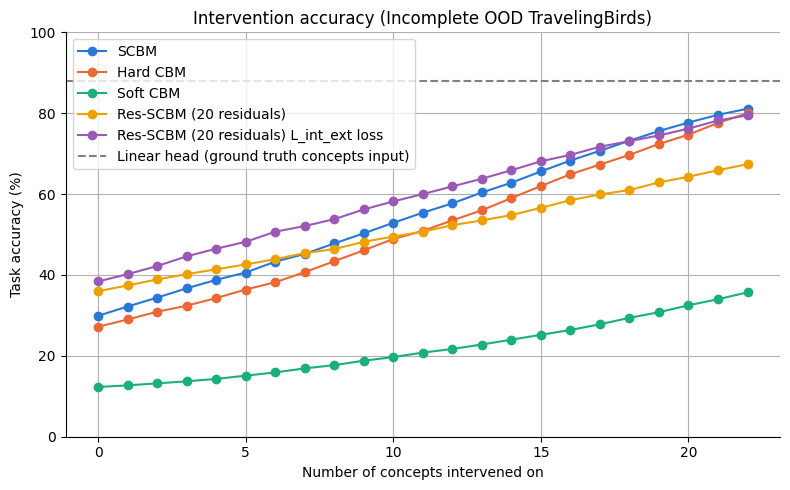

In [153]:
import matplotlib.pyplot as plt

# (label, model_dir, model_type) -- model_type selects the experiments/<model_type>/CUB/ subfolder
models = [("SCBM", "Mateo_025_2026-08-10_17-06-22_5b4d7", "scbm"),
          ("Hard CBM", "Mateo_025_2026-08-10_17-07-25_84e08", "cbm"),
          ("Soft CBM", "Mateo_025_soft_cbm_2026-08-14_16-10-47_b1b9b", "cbm"),
          ("Res-SCBM (20 residuals)", "Mateo_025_fixed_residuals_20_2026-08-10_17-06-05_7679e", "scbm_residual"),
          ("Res-SCBM (20 residuals) L_int_ext loss", "Mateo_025_fixed_emp_perc_residuals_20_L_int_extension_loss_weight_1_2026-08-11_12-01-55_9dbed", "scbm_residual"),
          #("Res-SCBM (5 residuals) L_int_ext", "Mateo_025_fixed_emp_perc_residuals_5_L_int_extension_loss_weight_1_2026-08-10_17-06-05_57592", "scbm_residual")
          ]

colors = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#9b59b6", "#e74c3c"]


colors = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#9b59b6", "#e74c3c"]

def plot(models, colors, title, linear_head_experiment=None, intervention_on_val_bool=False):


    fig, ax = plt.subplots(figsize=(8, 5))
    for (label, model_dir, model_type), color in zip(models, colors):
        concepts_intervened, y_accuracies, c_accuracies = extract_info_from_intervention_log(
            model_dir, model_type=model_type, intervention_on_val=intervention_on_val_bool
        )
        ax.plot(concepts_intervened, y_accuracies, marker="o", color=color, label=label)

    # Linear head ground truth concepts input
    if linear_head_experiment is not None:
        linear_head = retrieve_acc_from_log(os.path.join("experiments", "linear_head", "CUB", linear_head_experiment), linear_model=True)[0]
        ax.axhline(y=linear_head, color="gray", linestyle="--", label="Linear head (ground truth concepts input)")

    ax.set_xlabel("Number of concepts intervened on")
    ax.set_ylabel("Task accuracy (%)")
    ax.set_title(title)
    ax.legend()
    ax.grid(True)
    # y_max = 100
    ax.set_ylim(0, 100)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    plt.tight_layout()
    plt.show()
    
plot(models, colors, "Intervention accuracy (Incomplete OOD TravelingBirds)", linear_head_experiment="Mateo_025_2026-05-06_12-41-45_15c1b")

In [154]:
# Create dataframe for the results
import pandas as pd

# columns: model_name, num_concepts_intervened, y_accuracy, c_accuracy, y_auroc, c_auroc
# Only include 0, 11, and 22 concepts intervened
keep_concepts = {0, 11, 22}

rows = []
for label, model_dir, model_type in models:
    concepts_intervened, y_accuracies, c_accuracies, y_aurocs, c_aurocs = extract_info_from_intervention_log(
        model_dir, model_type=model_type, dataset="TravelingBirds", return_auroc=True
    )
    for n, y_acc, c_acc, y_auroc, c_auroc in zip(concepts_intervened, y_accuracies, c_accuracies, y_aurocs, c_aurocs):
        if n not in keep_concepts:
            continue
        rows.append({
            "model_name": label,
            "num_concepts_intervened": n,
            "y_accuracy": y_acc,
            "c_accuracy": c_acc,
            "y_auroc": y_auroc,
            "c_auroc": c_auroc,
        })

df = pd.DataFrame(rows, columns=["model_name", "num_concepts_intervened", "y_accuracy", "c_accuracy", "y_auroc", "c_auroc"])
df

,model_name,num_concepts_intervened,y_accuracy,c_accuracy,y_auroc,c_auroc
0,SCBM,0,29.9,89.9,92.5,91.2
1,SCBM,11,55.4,95.6,98.9,98.2
2,SCBM,22,81.1,100.0,99.9,100.0
3,Hard CBM,0,27.2,89.5,92.1,90.8
4,Hard CBM,11,50.9,94.7,98.6,97.7
5,Hard CBM,22,80.0,100.0,99.9,100.0
6,Soft CBM,0,12.3,89.8,89.4,91.1
7,Soft CBM,11,20.8,95.0,97.1,97.8
8,Soft CBM,22,35.7,100.0,99.6,100.0
9,Res-SCBM (20 residuals),0,36.0,90.1,94.2,91.3


## Incomplete ID TravelingBirds interventions

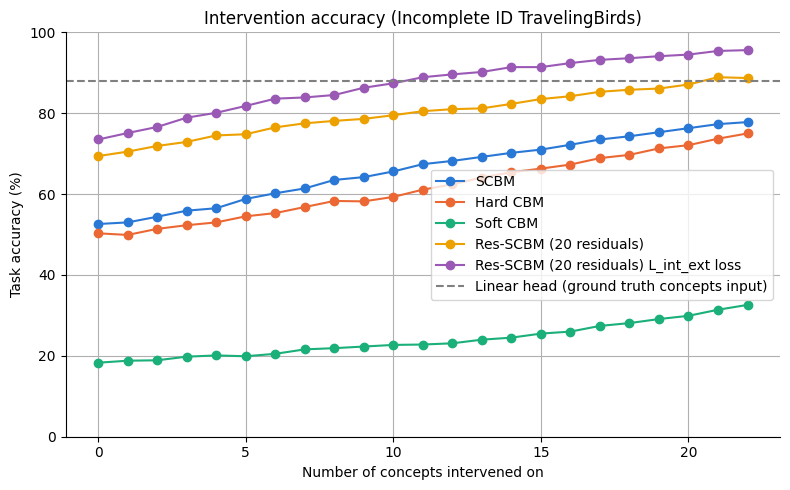

In [155]:
import matplotlib.pyplot as plt

# (label, model_dir, model_type) -- model_type selects the experiments/<model_type>/CUB/ subfolder
models = [("SCBM", "Mateo_025_2026-08-10_17-06-22_5b4d7", "scbm"),
          ("Hard CBM", "Mateo_025_2026-08-10_17-07-25_84e08", "cbm"),
          ("Soft CBM", "Mateo_025_soft_cbm_2026-08-14_16-10-47_b1b9b", "cbm"),
          ("Res-SCBM (20 residuals)", "Mateo_025_fixed_residuals_20_2026-08-10_17-06-05_7679e", "scbm_residual"),
          ("Res-SCBM (20 residuals) L_int_ext loss", "Mateo_025_fixed_emp_perc_residuals_20_L_int_extension_loss_weight_1_2026-08-11_12-01-55_9dbed", "scbm_residual"),
          
          #("Res-SCBM (5 residuals) L_int_ext", "Mateo_025_fixed_emp_perc_residuals_5_L_int_extension_loss_weight_1_2026-08-10_17-06-05_57592", "scbm_residual")
          ]

colors = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#9b59b6", "#e74c3c"]

def plot(models, colors, title, linear_head_experiment=None, intervention_on_val_bool=False):


    fig, ax = plt.subplots(figsize=(8, 5))
    for (label, model_dir, model_type), color in zip(models, colors):
        concepts_intervened, y_accuracies, c_accuracies = extract_info_from_intervention_log(
            model_dir, model_type=model_type, intervention_on_val=intervention_on_val_bool
        )
        ax.plot(concepts_intervened, y_accuracies, marker="o", color=color, label=label)

    # Linear head ground truth concepts input
    if linear_head_experiment is not None:
        linear_head = retrieve_acc_from_log(os.path.join("experiments", "linear_head", "CUB", linear_head_experiment), linear_model=True)[0]
        ax.axhline(y=linear_head, color="gray", linestyle="--", label="Linear head (ground truth concepts input)")

    ax.set_xlabel("Number of concepts intervened on")
    ax.set_ylabel("Task accuracy (%)")
    ax.set_title(title)
    ax.legend()
    ax.grid(True)
    # y_max = 100
    ax.set_ylim(0, 100)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    plt.tight_layout()
    plt.show()
    
plot(models, colors, "Intervention accuracy (Incomplete ID TravelingBirds)", linear_head_experiment="Mateo_025_2026-05-06_12-41-45_15c1b", intervention_on_val_bool=True)

In [156]:
# Create dataframe for the results
import pandas as pd

# columns: model_name, num_concepts_intervened, y_accuracy, c_accuracy, y_auroc, c_auroc
# Only include 0, 11, and 22 concepts intervened
keep_concepts = {0, 11, 22}

rows = []
for label, model_dir, model_type in models:
    concepts_intervened, y_accuracies, c_accuracies, y_aurocs, c_aurocs = extract_info_from_intervention_log(
        model_dir, model_type=model_type, dataset="TravelingBirds", return_auroc=True, intervention_on_val=True
    )
    for n, y_acc, c_acc, y_auroc, c_auroc in zip(concepts_intervened, y_accuracies, c_accuracies, y_aurocs, c_aurocs):
        if n not in keep_concepts:
            continue
        rows.append({
            "model_name": label,
            "num_concepts_intervened": n,
            "y_accuracy": y_acc,
            "c_accuracy": c_acc,
            "y_auroc": y_auroc,
            "c_auroc": c_auroc,
        })

df = pd.DataFrame(rows, columns=["model_name", "num_concepts_intervened", "y_accuracy", "c_accuracy", "y_auroc", "c_auroc"])
df

,model_name,num_concepts_intervened,y_accuracy,c_accuracy,y_auroc,c_auroc
0,SCBM,0,52.6,94.5,96.9,97.4
1,SCBM,11,67.4,97.8,99.5,99.6
2,SCBM,22,77.8,100.0,99.9,100.0
3,Hard CBM,0,50.3,94.2,96.3,97.1
4,Hard CBM,11,61.1,97.0,99.2,99.2
5,Hard CBM,22,75.0,100.0,99.9,100.0
6,Soft CBM,0,18.3,94.1,94.5,96.9
7,Soft CBM,11,22.8,96.9,98.1,99.1
8,Soft CBM,22,32.6,100.0,99.5,100.0
9,Res-SCBM (20 residuals),0,69.4,94.6,98.4,97.5


### SCBM Residual model ID and OOD 

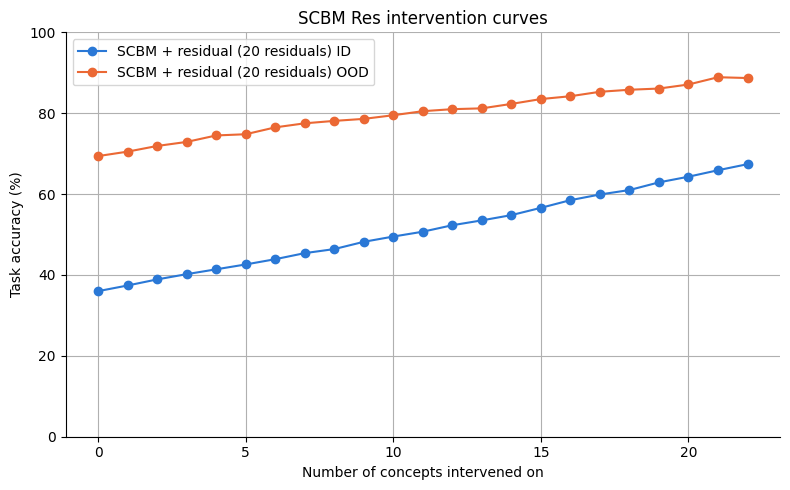

In [157]:
scbm_res_id_intervention = extract_info_from_intervention_log(
    "Mateo_025_fixed_residuals_20_2026-08-10_17-06-05_7679e", model_type="scbm_residual", dataset="TravelingBirds", return_auroc=True
)

scbm_res_ood_intervention = extract_info_from_intervention_log(
    "Mateo_025_fixed_residuals_20_2026-08-10_17-06-05_7679e", model_type="scbm_residual", dataset="TravelingBirds", return_auroc=True, intervention_on_val=True
)


# Plot the intervention curves for ID and OOD on the same plot
fig, ax = plt.subplots(figsize=(8, 5))
concepts_intervened_id, y_accuracies_id, c_accuracies_id, y_aurocs_id, c_aurocs_id = scbm_res_id_intervention
concepts_intervened_ood, y_accuracies_ood, c_accuracies_ood, y_aurocs_ood, c_aurocs_ood = scbm_res_ood_intervention 

# Plot ID intervention curve
ax.plot(concepts_intervened_id, y_accuracies_id, marker="o", color="#2a78d6", label="SCBM + residual (20 residuals) ID")
# Plot OOD intervention curve
ax.plot(concepts_intervened_ood, y_accuracies_ood, marker="o", color="#eb6834", label="SCBM + residual (20 residuals) OOD")

ax.set_xlabel("Number of concepts intervened on")
ax.set_ylabel("Task accuracy (%)")
ax.set_title("SCBM Res intervention curves")
ax.legend()
ax.grid(True)
# y_max = 100
ax.set_ylim(0, 100)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.show()




### Residual activation

In [158]:
primary_metric = "mean_abs_change" #"normalized_sensitivity"

In [159]:
NUM_CONCEPTS = 22

# ------------------------------------------------------------
# 1. Experiment paths
# ------------------------------------------------------------

scbm_res_with_l_int_ext_loss = os.path.join(
    "experiments",
    "scbm_residual",
    "TravelingBirds",
    "Mateo_025_fixed_residuals_20_2026-08-10_17-06-05_7679e"
    #"Mateo_025_fixed_emp_perc_residuals_20_L_int_extension_loss_weight_1_2026-08-11_12-01-55_9dbed"
)

test_bg_train_path = os.path.join(
    scbm_res_with_l_int_ext_loss,
    "test_bg_train"
)

test_bg_test_path = os.path.join(
    scbm_res_with_l_int_ext_loss,
    "test_bg_test"
)


# ------------------------------------------------------------
# 2. Load concept and residual means for both renders
# ------------------------------------------------------------

C_R_bg_train = torch.load(
    os.path.join(test_bg_train_path, "concepts_residuals_pred_probs_mean.pt"),
    map_location="cpu"
)

C_R_bg_test = torch.load(
    os.path.join(test_bg_test_path, "concepts_residuals_pred_probs_mean.pt"),
    map_location="cpu"
)

C_bg_train = C_R_bg_train[:, :NUM_CONCEPTS].detach().cpu().numpy()
C_bg_test  = C_R_bg_test[:,  :NUM_CONCEPTS].detach().cpu().numpy()

R_bg_train = C_R_bg_train[:, NUM_CONCEPTS:].detach().cpu().numpy()
R_bg_test  = C_R_bg_test[:,  NUM_CONCEPTS:].detach().cpu().numpy()

print("concepts:", C_bg_train.shape, " residuals:", R_bg_train.shape)

assert C_bg_train.shape == C_bg_test.shape
assert R_bg_train.shape == R_bg_test.shape

# Change this two image paths
# ------------------------------------------------------------
# 3. Verify the two renders are row-aligned 
# ------------------------------------------------------------


def rel_after_bg_root(path):
    """<...>/TravelingBirds/train/001.Black_footed_Albatross/x.jpg -> 001.Black_footed_Albatross/x.jpg

    Drops everything up to and including the last `train`/`test` folder component,
    so the two background renderings of the same photo compare equal.
    """
    parts = path.strip().split("/")
    i = max(idx for idx, part in enumerate(parts) if part in ("train", "test"))
    return "/".join(parts[i + 1:])


def read_img_paths(folder_path):
    with open(os.path.join(folder_path, "img_paths.txt"), "r") as f:
        return [rel_after_bg_root(line) for line in f if line.strip()]


img_paths_train = read_img_paths(test_bg_train_path)
img_paths_test = read_img_paths(test_bg_test_path)


# check the two renderings are row-aligned (same bird, same labels, different background)
if img_paths_train == img_paths_test:
    print(f"Row-aligned: {len(img_paths_train)} images match between test_bg_train and test_bg_test.")
else:
    n_mismatch = sum(a != b for a, b in zip(img_paths_train, img_paths_test))
    print(
        f"NOT aligned: {len(img_paths_train)} vs {len(img_paths_test)} rows, "
        f"{n_mismatch} mismatches in the overlap."
    )


concepts: (5794, 22)  residuals: (5794, 20)
Row-aligned: 5794 images match between test_bg_train and test_bg_test.


In [160]:
# ============================================================
# Shared background-swap analysis
#
# The concept and residual channels get exactly the same treatment,
# so it is written once here and applied to both. Both renders show
# the same bird with the same labels, so any movement between them is
# caused purely by the background.
# ============================================================


def channel_shift_stats(A_train, A_test, channel_name):
    """Per-dimension shift of one channel under the background swap."""

    d = A_train.shape[1]

    std = A_train.std(axis=0)
    mean_abs_activation = np.abs(A_train).mean(axis=0)
    mean_abs_change = np.abs(A_test - A_train).mean(axis=0)

    corr = np.array([
        np.corrcoef(A_train[:, j], A_test[:, j])[0, 1]
        for j in range(d)
    ])

    return pd.DataFrame({
        "channel": channel_name,
        "dim": np.arange(d),
        "std_bg_train": std,
        "mean_abs_activation": mean_abs_activation,
        "mean_abs_change": mean_abs_change,
        # shift in units of the dimension's own spread
        "normalized_sensitivity": mean_abs_change / (std + 1e-8),
        # shift relative to the dimension's typical activation magnitude
        "relative_change": mean_abs_change / (mean_abs_activation + 1e-8),
        "bg_swap_correlation": corr,
    })


def per_class_shift_stats(A_train, A_test, class_ids, channel_name):
    """Same shift, split by class.

    Normalized by the GLOBAL per-dimension std rather than a per-class one,
    so that different classes stay comparable to each other.
    """

    std = A_train.std(axis=0)
    rows = []

    for class_id in np.unique(class_ids):

        mask = class_ids == class_id

        mean_class_change = np.abs(
            A_test[mask] - A_train[mask]
        ).mean(axis=0)

        for dim in range(A_train.shape[1]):
            rows.append({
                "channel": channel_name,
                "class_id": int(class_id),
                "dim": dim,
                "mean_abs_change": mean_class_change[dim],
                "normalized_sensitivity":
                    mean_class_change[dim] / (std[dim] + 1e-8),
            })

    return pd.DataFrame(rows)


def plot_channel_shift(df, metric="normalized_sensitivity", ax=None):
    """Per-dimension bar plot of one channel's background sensitivity."""

    if ax is None:
        _, ax = plt.subplots(figsize=(10, 4))

    plot_df = df.sort_values("dim")
    channel = plot_df["channel"].iloc[0]

    ax.bar(plot_df["dim"], plot_df[metric])
    ax.set_xticks(plot_df["dim"])
    ax.set_xlabel(f"{channel} dimension")
    ax.set_ylabel(metric)
    ax.grid(axis="y", alpha=0.3)

    return ax


In [161]:
residual_shift_df = channel_shift_stats(R_bg_train, R_bg_test, "residual")
concept_shift_df  = channel_shift_stats(C_bg_train, C_bg_test, "concept")

shift_df = pd.concat(
    [concept_shift_df, residual_shift_df],
    ignore_index=True
)

residual_shift_df.sort_values(
    "normalized_sensitivity",
    ascending=False
)


,channel,dim,std_bg_train,mean_abs_activation,mean_abs_change,normalized_sensitivity,relative_change,bg_swap_correlation
0,residual,0,0.436478,0.625999,0.248004,0.568194,0.396173,0.542089
10,residual,10,0.451095,0.604518,0.244686,0.542427,0.404762,0.555122
19,residual,19,0.443583,0.609919,0.231752,0.522456,0.379972,0.582649
15,residual,15,0.444319,0.631845,0.223833,0.503766,0.354253,0.596341
4,residual,4,0.429047,0.648446,0.213761,0.498221,0.329651,0.609097
12,residual,12,0.423250,0.675463,0.195701,0.462377,0.289728,0.628726
7,residual,7,0.452104,0.572873,0.204609,0.452571,0.357163,0.663742
17,residual,17,0.441126,0.599956,0.194113,0.440039,0.323545,0.686188
3,residual,3,0.455562,0.556285,0.199288,0.437454,0.358247,0.675983
18,residual,18,0.433883,0.619804,0.189772,0.437381,0.306181,0.689409


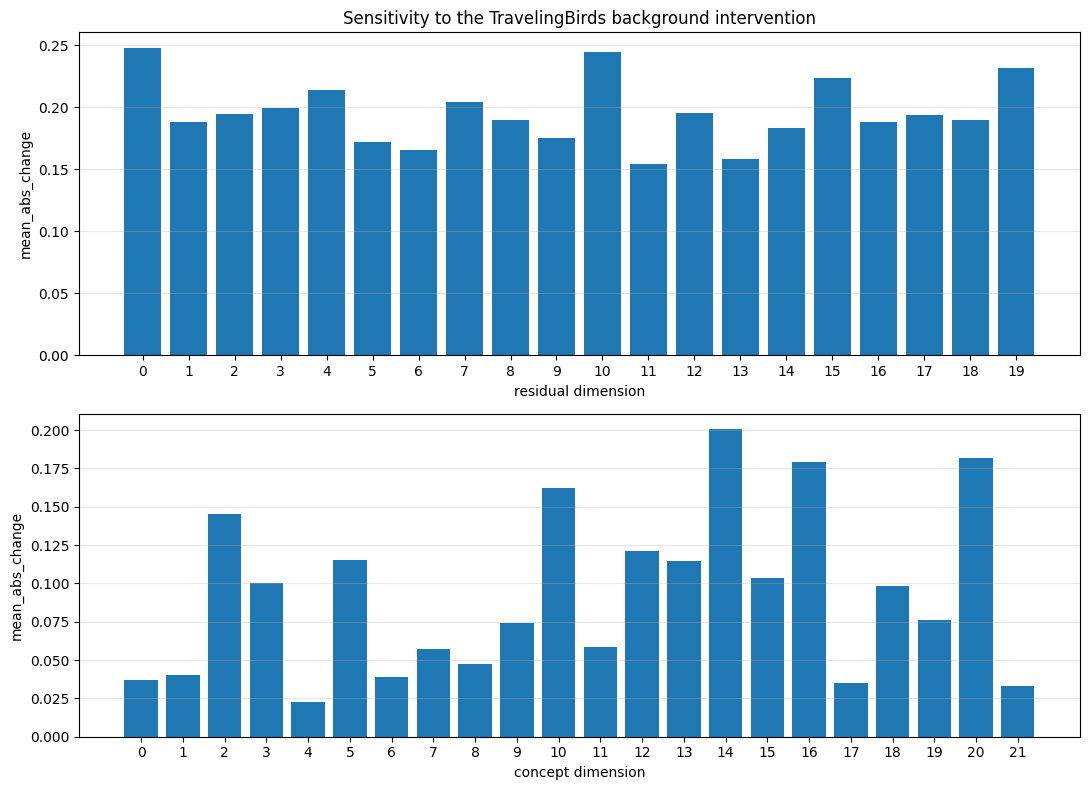

In [162]:
fig, axes = plt.subplots(2, 1, figsize=(11, 8))

for ax, df in zip(axes, (residual_shift_df, concept_shift_df)):
    plot_channel_shift(df, metric=primary_metric, ax=ax)

axes[0].set_title(
    "Sensitivity to the TravelingBirds background intervention"
)

fig.tight_layout()
plt.show()


### Per class shift following background shift

In [163]:
y_test_bg = torch.load(os.path.join(test_bg_test_path, "y_true.pt"))

In [164]:
per_class_shift_df = pd.concat(
    [
        per_class_shift_stats(C_bg_train, C_bg_test, y_test_bg, "concept"),
        per_class_shift_stats(R_bg_train, R_bg_test, y_test_bg, "residual"),
    ],
    ignore_index=True
)

# Rank the dimensions by background sensitivity WITHIN each class, so reading
# down a class block gives that class's most background-sensitive dimensions
# first. Both channels are ranked against each other: they are MC-mean Bernoulli
# probabilities feeding the same head, so mean_abs_change carries the same units
# in either block. Read the `channel` column alongside `dim`, which restarts at
# 0 per channel.
per_class_shift_df = per_class_shift_df.sort_values(
    ["class_id", "mean_abs_change"],
    ascending=[True, False],
).reset_index(drop=True)

display(per_class_shift_df)

per_class_shift_df.to_csv("TravelingBirds_analysis/per_class_shift_df.csv", index=False)

,channel,class_id,dim,mean_abs_change,normalized_sensitivity
0,concept,0,1,0.431766,2.283912
1,residual,0,8,0.423498,0.952341
2,residual,0,14,0.408156,0.917265
3,residual,0,19,0.349330,0.787520
4,concept,0,20,0.325471,0.725289
...,...,...,...,...,...
8395,concept,199,1,0.001362,0.007204
8396,concept,199,4,0.001171,0.006521
8397,concept,199,6,0.001149,0.005328
8398,concept,199,17,0.001022,0.004990


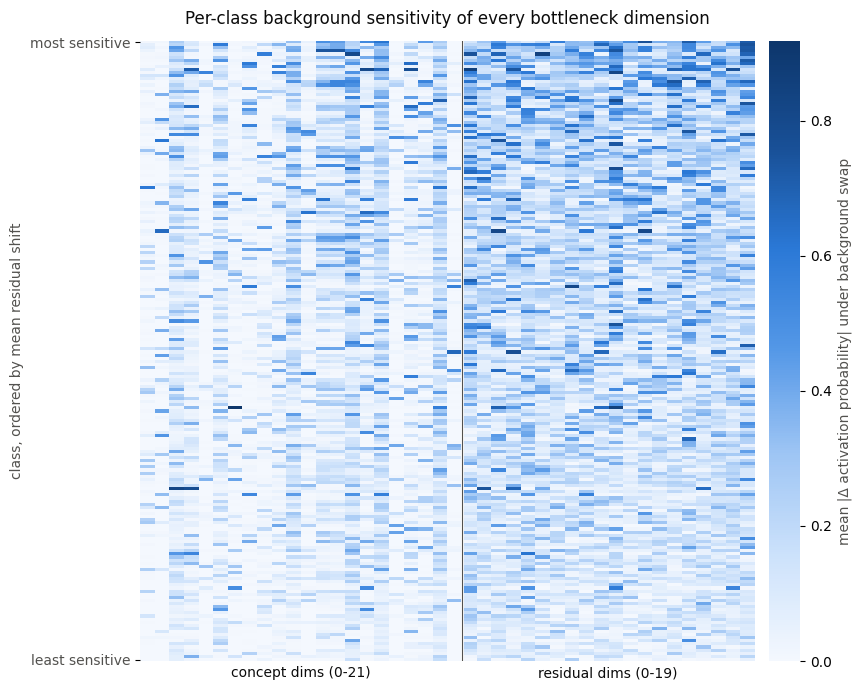

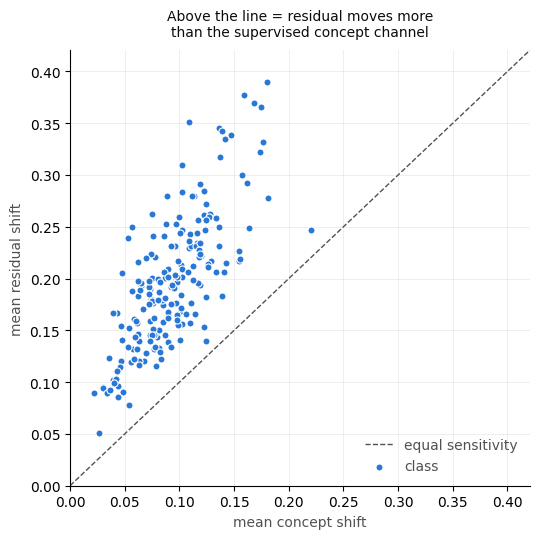

channel,concept,residual
count,200.000,200.000
mean,0.093,0.196
std,0.035,0.064
min,0.022,0.051
25%,0.069,0.150
50%,0.089,0.193
75%,0.116,0.232
max,0.220,0.389


In [165]:
# ============================================================
# Class-wise view of the background-swap shift
# ============================================================
#
# Two forms, both reading `mean_abs_change` (units: activation probability,
# so concept and residual dimensions are directly comparable):
#
#   1. heatmap  - classes x every bottleneck dimension; shows *which* dims
#                 carry a class's background sensitivity.
#   2. scatter  - one point per class; shows *how much* the residual channel
#                 moves relative to the concept channel, which is supervised
#                 to be background-invariant and therefore acts as a floor.

from matplotlib.colors import LinearSegmentedColormap


# Single-hue sequential ramp: near-zero recedes into the surface, larger
# shift = darker. Magnitude data, so no diverging midpoint and no rainbow.
SHIFT_CMAP = LinearSegmentedColormap.from_list(
    "shift_blue",
    ["#f4f8fe", "#cde2fb", "#9ec5f4", "#5598e7", "#2a78d6", "#184f95", "#0d366b"],
)

INK = "#0b0b0b"
INK_MUTED = "#52514e"


def plot_class_dim_heatmap(df, metric="mean_abs_change", order_by="residual"):
    """Classes x bottleneck dimensions, coloured by background-swap shift."""

    grid = df.pivot_table(
        index="class_id",
        columns=["channel", "dim"],
        values=metric,
    ).sort_index(axis=1)

    # Order classes by how background-sensitive `order_by` is on average, so
    # class-level structure shows up as a gradient instead of noise.
    class_order = grid[order_by].mean(axis=1).sort_values(ascending=False).index
    grid = grid.loc[class_order]

    n_concept = grid["concept"].shape[1]
    n_residual = grid.shape[1] - n_concept

    fig, ax = plt.subplots(figsize=(9, 7))

    im = ax.imshow(
        grid.values,
        aspect="auto",
        cmap=SHIFT_CMAP,
        vmin=0,
        interpolation="nearest",
    )

    # Separate the two channel blocks; dim indices restart at 0 per channel.
    ax.axvline(n_concept - 0.5, color="white", lw=2)
    ax.axvline(n_concept - 0.5, color=INK_MUTED, lw=0.8)

    ax.set_xticks([n_concept / 2 - 0.5, n_concept + n_residual / 2 - 0.5])
    ax.set_xticklabels(
        [f"concept dims (0-{n_concept - 1})", f"residual dims (0-{n_residual - 1})"],
        color=INK,
    )
    ax.tick_params(axis="x", length=0)

    ax.set_ylabel(f"class, ordered by mean {order_by} shift", color=INK_MUTED)
    ax.set_yticks([0, len(class_order) - 1])
    ax.set_yticklabels(["most sensitive", "least sensitive"], color=INK_MUTED)

    for spine in ax.spines.values():
        spine.set_visible(False)

    cbar = fig.colorbar(im, ax=ax, pad=0.02)
    cbar.set_label(
        "mean |\u0394 activation probability| under background swap",
        color=INK_MUTED,
    )
    cbar.outline.set_visible(False)

    ax.set_title(
        "Per-class background sensitivity of every bottleneck dimension",
        color=INK,
        pad=12,
    )

    fig.tight_layout()
    return fig, ax, grid


def plot_class_channel_scatter(df, metric="mean_abs_change"):
    """One point per class: mean concept shift vs mean residual shift."""

    per_class = (
        df.groupby(["class_id", "channel"])[metric].mean().unstack("channel")
    )

    fig, ax = plt.subplots(figsize=(5.5, 5.5))

    lim = float(per_class.to_numpy().max()) * 1.08

    ax.plot(
        [0, lim], [0, lim],
        color=INK_MUTED, lw=1, ls="--", zorder=1,
        label="equal sensitivity",
    )
    ax.scatter(
        per_class["concept"], per_class["residual"],
        s=26, color="#2a78d6", edgecolor="white", linewidth=0.8,
        zorder=2, label="class",
    )

    ax.set_xlim(0, lim)
    ax.set_ylim(0, lim)
    ax.set_xlabel("mean concept shift", color=INK_MUTED)
    ax.set_ylabel("mean residual shift", color=INK_MUTED)
    ax.set_title(
        "Above the line = residual moves more\nthan the supervised concept channel",
        color=INK, fontsize=10, pad=10,
    )
    ax.grid(alpha=0.25, lw=0.6)
    ax.set_axisbelow(True)
    for side in ("top", "right"):
        ax.spines[side].set_visible(False)
    ax.legend(frameon=False, loc="lower right", labelcolor=INK_MUTED)

    fig.tight_layout()
    return fig, ax, per_class


_, _, shift_grid = plot_class_dim_heatmap(per_class_shift_df)
plt.show()

_, _, per_class_channel_means = plot_class_channel_scatter(per_class_shift_df)
plt.show()

display(
    per_class_channel_means.describe().round(3)
)

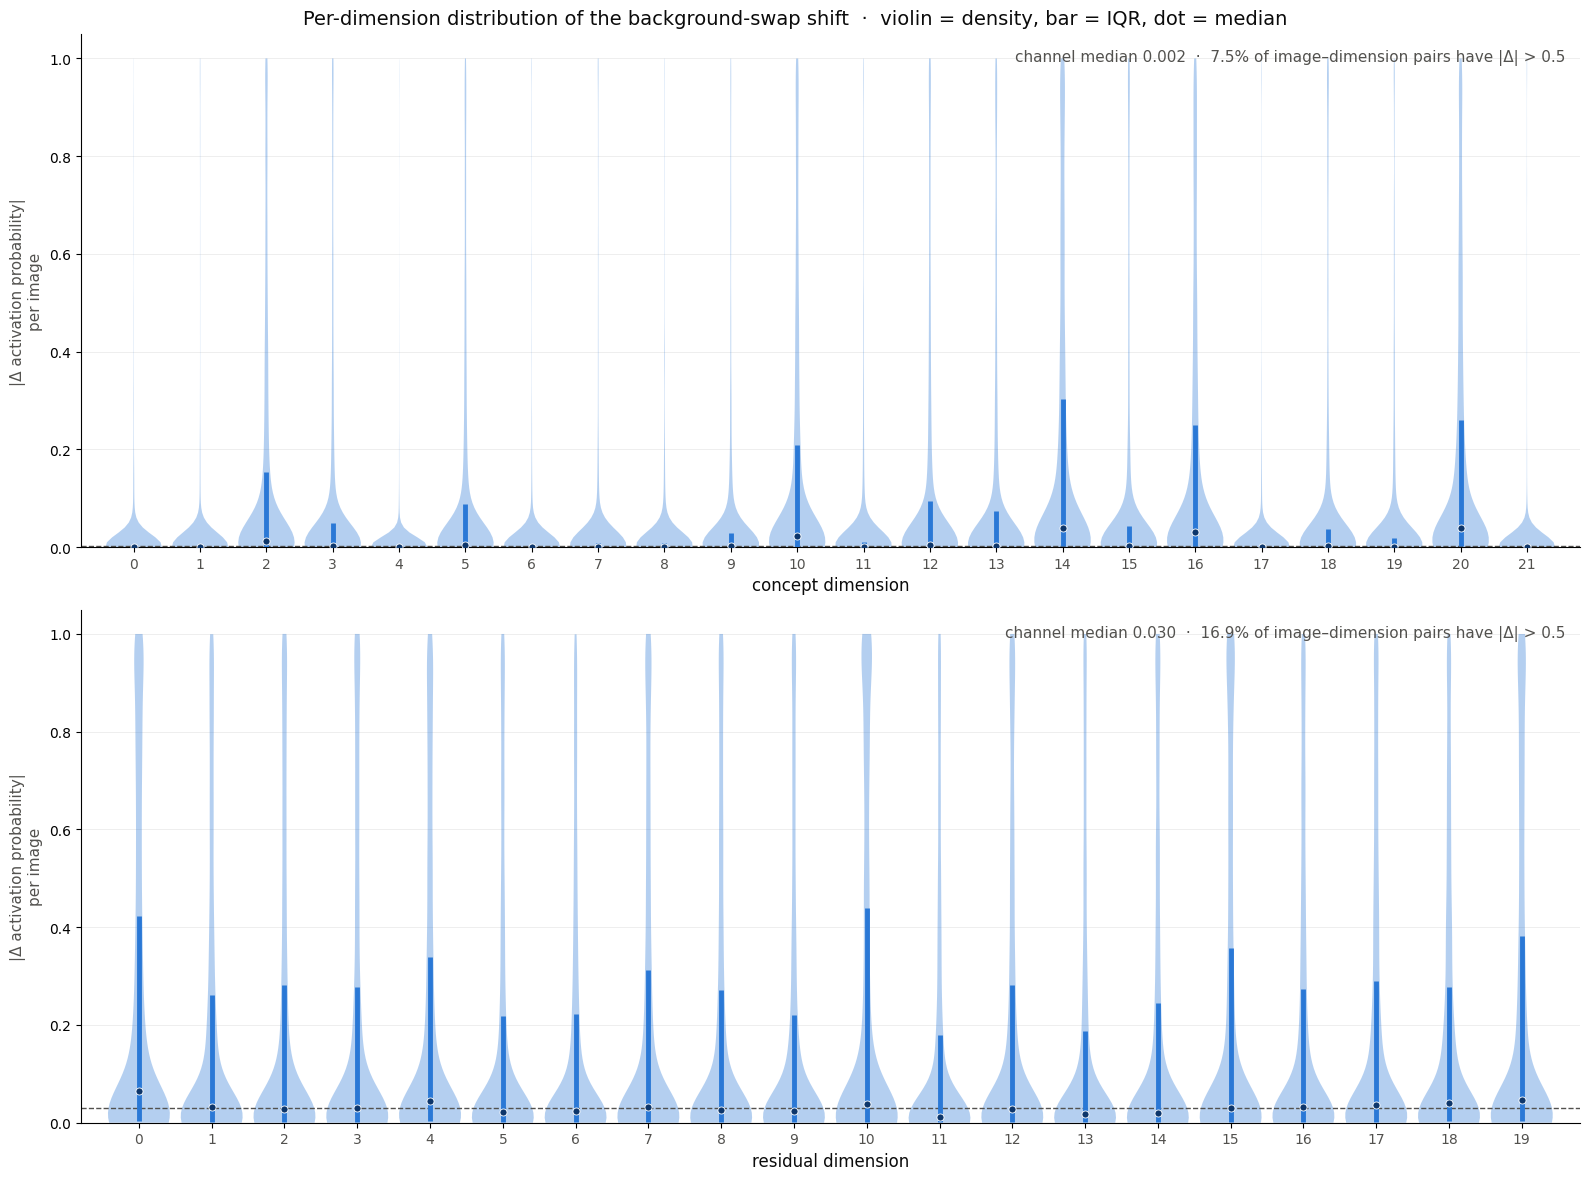

 concept: median 0.002 | mean 0.093 | P(>0.5) 7.5% | per-dim medians 0.000-0.039
residual: median 0.030 | mean 0.196 | P(>0.5) 16.9% | per-dim medians 0.012-0.065


In [166]:
# ============================================================
# Per-dimension distribution of the background-swap shift
# ============================================================
#
# One violin per dimension, over the paired renders: every image contributes
# |p_bg_test - p_bg_train| for that dimension. This is the distribution the
# per-class `mean_abs_change` table aggregates away -- these shifts are
# strongly zero-inflated with a tail all the way to 1.0, so a mean alone
# hides both the "mostly does not move" mass and the outright flips.
#
# Both panels share the y-axis: concept and residual dimensions are activation
# probabilities feeding the same head, so the scale is common.


# Palette constants, repeated here so this cell runs standalone.
INK = "#0b0b0b"
INK_MUTED = "#52514e"
HUE = "#2a78d6"        # sequential blue, same hue as the class-wise heatmap
HUE_DARK = "#0d366b"   # darkest step, for the median marker


def plot_abs_change_distributions(pairs, metric_name="|Δ activation probability|"):
    """Per-dimension distribution of the background-swap shift.

    pairs: list of (channel_name, A_bg_train, A_bg_test), one panel each.
    """

    deltas = [(name, np.abs(test - train)) for name, train, test in pairs]

    # Stacked vertically, one panel per channel, on a shared y-axis: the two
    # channels stay directly comparable while each panel gets the full width.
    fig, axes = plt.subplots(
        len(deltas), 1,
        figsize=(16, 6.0 * len(deltas)),
        sharey=True,
    )
    axes = np.atleast_1d(axes)

    for ax, (name, delta) in zip(axes, deltas):

        d = delta.shape[1]
        positions = np.arange(d)

        parts = ax.violinplot(
            [delta[:, j] for j in positions],
            positions=positions,
            widths=0.85,
            showextrema=False,
            showmedians=False,
        )
        for body in parts["bodies"]:
            body.set_facecolor(HUE)
            body.set_alpha(0.35)
            body.set_edgecolor("none")

        # Median + IQR over the density, so the summary is readable without
        # hiding the shape of the distribution.
        q1, med, q3 = np.percentile(delta, [25, 50, 75], axis=0)
        ax.vlines(positions, q1, q3, color=HUE, lw=3.5, zorder=3)
        ax.scatter(positions, med, s=26, color=HUE_DARK, zorder=4,
                   edgecolor="white", linewidth=0.6)

        ax.set_xticks(positions)
        ax.set_xticklabels(positions, fontsize=10, color=INK_MUTED)
        ax.set_xlabel(f"{name} dimension", color=INK, fontsize=12)
        ax.set_xlim(-0.8, d - 0.2)
        ax.grid(axis="y", alpha=0.25, lw=0.6)
        ax.set_axisbelow(True)
        for side in ("top", "right"):
            ax.spines[side].set_visible(False)

        # Channel-level median, labelled at a fixed corner so it never
        # collides with the axis when the median sits near zero.
        ax.axhline(np.median(delta), color=INK_MUTED, lw=1, ls="--", zorder=2)
        ax.annotate(
            f"channel median {np.median(delta):.3f}"
            f"  ·  {(delta > 0.5).mean():.1%} of image–dimension pairs have |Δ| > 0.5",
            xy=(0.99, 0.97), xycoords="axes fraction",
            ha="right", va="top", fontsize=11, color=INK_MUTED,
        )

    for ax in axes:
        ax.set_ylabel(f"{metric_name}\nper image", color=INK_MUTED, fontsize=11)
        ax.tick_params(axis="y", labelsize=10)
    axes[0].set_ylim(bottom=0)

    fig.suptitle(
        "Per-dimension distribution of the background-swap shift"
        "  ·  violin = density, bar = IQR, dot = median",
        color=INK, fontsize=14,
    )
    fig.tight_layout()
    return fig, axes


fig, axes = plot_abs_change_distributions([
    ("concept", C_bg_train, C_bg_test),
    ("residual", R_bg_train, R_bg_test),
])
plt.show()


# Numeric companion to the figure.
for name, train, test in [
    ("concept", C_bg_train, C_bg_test),
    ("residual", R_bg_train, R_bg_test),
]:
    delta = np.abs(test - train)
    print(
        f"{name:>8}: median {np.median(delta):.3f} | mean {delta.mean():.3f} | "
        f"P(>0.5) {(delta > 0.5).mean():.1%} | "
        f"per-dim medians {np.median(delta, axis=0).min():.3f}-"
        f"{np.median(delta, axis=0).max():.3f}"
    )

### Per-dimension numbers behind the violins

The violin figure shows the *shape* of each dimension's background-swap shift;
these two cells give the numbers and the unpacked distributions.

* the table is one row per bottleneck dimension (`dim` restarts at 0 per
  `channel`) with `mean` / `median` / `min` / `max` of
  `|p_bg_test - p_bg_train|` over the paired renders, plus `std`, the quartiles
  and the flip rate `frac_gt_0.5`;
* the small-multiples grid is one histogram per dimension, log-count so the
  zero spike does not swallow the tail.

`min` is near-zero for essentially every dimension and `max` saturates at 1.0 on
at least one image for most of them &mdash; both are order statistics over ~6k
images, so they describe the extremes, not the behaviour. `median` vs `mean` and
`frac_gt_0.5` are what separate the channels.


In [167]:
# ============================================================
# Per-dimension summary of the background-swap shift
# ============================================================
#
# One row per bottleneck dimension, over the same paired renders the violins
# above are drawn from: every image contributes |p_bg_test - p_bg_train| for
# that dimension, and the row summarises that distribution. Concept and
# residual rows are directly comparable -- both are activation probabilities
# feeding the same head -- but `dim` restarts at 0 per channel, so always read
# it next to `channel`.
#
# Read `median` against `mean`: the shifts are zero-inflated, so a median near
# zero with a mean well above it means the dimension holds still on most images
# and flips on a few. `max` is a single-image worst case over ~1e4 images, not
# a trend -- `q75` and `frac_gt_0.5` are the honest tail summaries.


def per_dim_delta_summary(pairs):
    """Per-dimension summary of |Delta activation probability| under the swap.

    pairs: list of (channel_name, A_bg_train, A_bg_test), same argument shape
    as `plot_abs_change_distributions`.
    """

    rows = []

    for name, train, test in pairs:

        delta = np.abs(test - train)
        q25, med, q75 = np.percentile(delta, [25, 50, 75], axis=0)

        for j in range(delta.shape[1]):
            rows.append({
                "channel": name,
                "dim": j,
                "mean": delta[:, j].mean(),
                "median": med[j],
                "min": delta[:, j].min(),
                "max": delta[:, j].max(),
                "std": delta[:, j].std(),
                "q25": q25[j],
                "q75": q75[j],
                "frac_gt_0.5": (delta[:, j] > 0.5).mean(),
            })

    return pd.DataFrame(rows)


delta_summary_df = per_dim_delta_summary([
    ("concept", C_bg_train, C_bg_test),
    ("residual", R_bg_train, R_bg_test),
])

# Full table, in channel/dim order -- the companion to the violin figure.
display(delta_summary_df.round(4))

# Channel-level aggregate of the same numbers.
display(
    delta_summary_df
    .groupby("channel")[["mean", "median", "min", "max", "frac_gt_0.5"]]
    .agg(["mean", "min", "max"])
    .round(4)
)

# Most background-sensitive dimensions of either channel first.
display(
    delta_summary_df
    .sort_values("median", ascending=False)
    .round(4)
    .head(15)
)

delta_summary_df.to_csv(
    "TravelingBirds_analysis/per_dim_delta_summary.csv", index=False
)

,channel,dim,mean,median,min,max,std,q25,q75,frac_gt_0.5
0,concept,0,0.0367,0.0003,0.0,0.9996,0.1356,0.0000,0.0031,0.0264
1,concept,1,0.0402,0.0002,0.0,0.9999,0.1573,0.0000,0.0017,0.0359
2,concept,2,0.1450,0.0120,0.0,1.0000,0.2539,0.0006,0.1545,0.1134
3,concept,3,0.1004,0.0034,0.0,1.0000,0.2231,0.0002,0.0500,0.0792
4,concept,4,0.0223,0.0002,0.0,0.9979,0.1115,0.0000,0.0013,0.0167
5,concept,5,0.1155,0.0054,0.0,0.9998,0.2307,0.0004,0.0877,0.0915
6,concept,6,0.0391,0.0005,0.0,0.9999,0.1477,0.0001,0.0035,0.0321
7,concept,7,0.0569,0.0008,0.0,1.0000,0.1789,0.0001,0.0078,0.0463
8,concept,8,0.0474,0.0012,0.0,0.9997,0.1530,0.0002,0.0089,0.0342
9,concept,9,0.0742,0.0026,0.0,0.9997,0.1884,0.0003,0.0295,0.0547


mean                  median                  min            \
            mean     min     max    mean     min     max mean  min  max   
channel                                                                   
concept   0.0928  0.0223  0.2006  0.0079  0.0002  0.0390  0.0  0.0  0.0   
residual  0.1957  0.1542  0.2480  0.0315  0.0115  0.0653  0.0  0.0  0.0   

             max              frac_gt_0.5                  
            mean     min  max        mean     min     max  
channel                                                    
concept   0.9998  0.9979  1.0      0.0747  0.0167  0.1691  
residual  0.9999  0.9992  1.0      0.1693  0.1272  0.2273

,channel,dim,mean,median,min,max,std,q25,q75,frac_gt_0.5
22,residual,0,0.2480,0.0653,0.0,0.9999,0.3242,0.0039,0.4221,0.2247
41,residual,19,0.2318,0.0462,0.0,0.9999,0.3180,0.0026,0.3827,0.2085
26,residual,4,0.2138,0.0449,0.0,0.9998,0.3000,0.0030,0.3392,0.1895
40,residual,18,0.1898,0.0407,0.0,0.9998,0.2750,0.0026,0.2776,0.1534
14,concept,14,0.2006,0.0390,0.0,1.0000,0.2898,0.0025,0.3042,0.1691
20,concept,20,0.1819,0.0386,0.0,0.9999,0.2673,0.0030,0.2607,0.1479
32,residual,10,0.2447,0.0382,0.0,1.0000,0.3390,0.0013,0.4399,0.2273
39,residual,17,0.1941,0.0367,0.0,1.0000,0.2833,0.0023,0.2901,0.1619
29,residual,7,0.2046,0.0323,0.0,1.0000,0.3003,0.0015,0.3120,0.1778
16,concept,16,0.1790,0.0319,0.0,1.0000,0.2714,0.0019,0.2497,0.1460


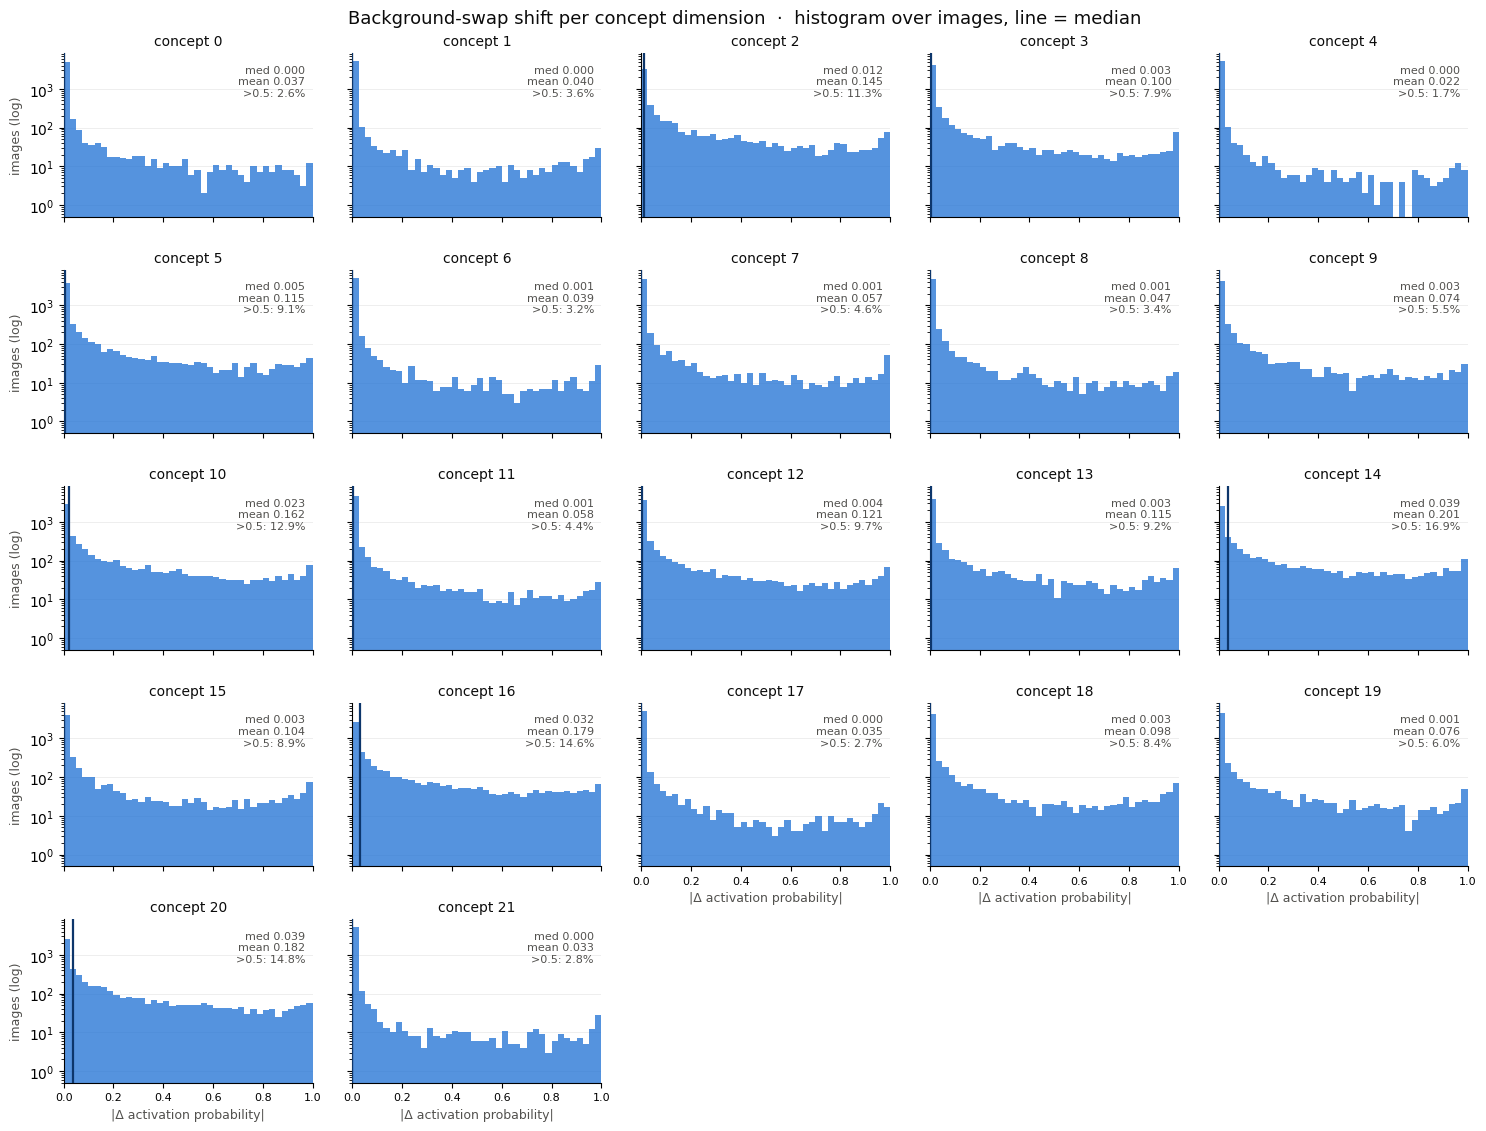

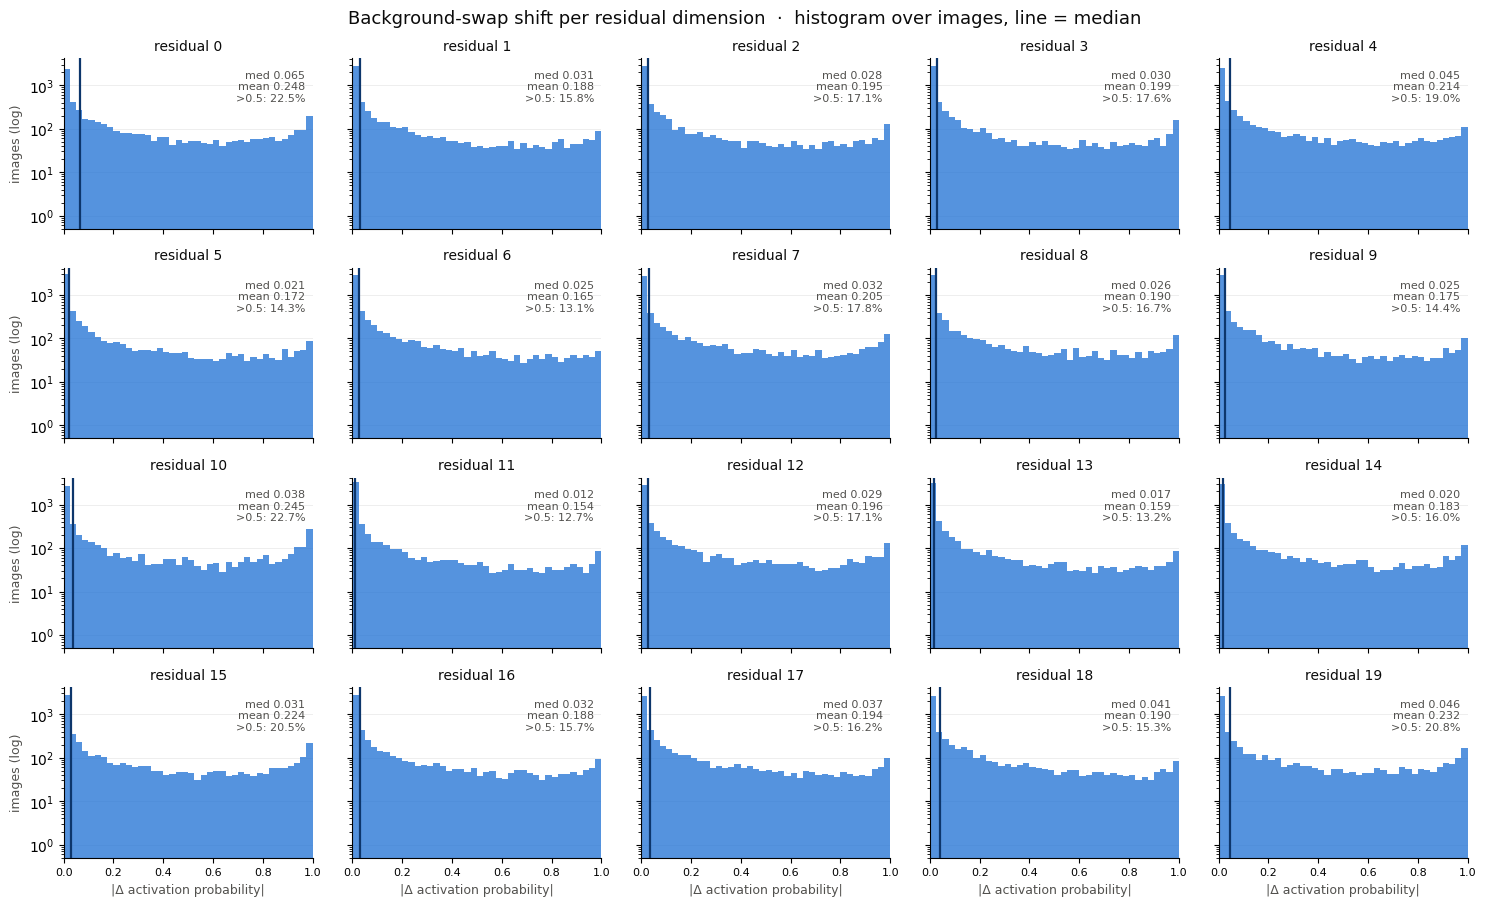

In [168]:
# ============================================================
# One panel per dimension: the full shape behind each violin
# ============================================================
#
# The violin figure compresses each dimension into a density strip; this is the
# same data unpacked, one histogram per dimension, so the zero spike and the
# tail can be read separately. Axes are shared across every panel of both
# figures (x on [0, 1], same y), so panels stay comparable at a glance.
#
# The count axis is logarithmic on purpose: the distributions are strongly
# zero-inflated, and on a linear axis the near-zero bin flattens everything
# else into the baseline -- exactly the tail these figures exist to show.

# Palette constants, repeated here so this cell runs standalone.
INK = "#0b0b0b"
INK_MUTED = "#52514e"
HUE = "#2a78d6"
HUE_DARK = "#0d366b"


def plot_per_dim_delta_grid(name, A_train, A_test, ncols=5, bins=40):
    """Small multiples of |Delta activation probability|, one panel per dim."""

    delta = np.abs(A_test - A_train)
    d = delta.shape[1]
    nrows = int(np.ceil(d / ncols))

    fig, axes = plt.subplots(
        nrows, ncols,
        figsize=(3.0 * ncols, 2.3 * nrows),
        sharex=True, sharey=True,
    )
    axes = np.atleast_1d(axes).ravel()

    edges = np.linspace(0.0, 1.0, bins + 1)

    for j in range(d):

        ax = axes[j]
        ax.hist(delta[:, j], bins=edges, color=HUE, alpha=0.8, edgecolor="none")

        med = np.median(delta[:, j])
        ax.axvline(med, color=HUE_DARK, lw=1.6, zorder=3)

        ax.set_title(f"{name} {j}", fontsize=10, color=INK)
        ax.annotate(
            f"med {med:.3f}\nmean {delta[:, j].mean():.3f}"
            f"\n>0.5: {(delta[:, j] > 0.5).mean():.1%}",
            xy=(0.97, 0.93), xycoords="axes fraction",
            ha="right", va="top", fontsize=8, color=INK_MUTED,
        )

        ax.grid(axis="y", alpha=0.25, lw=0.6)
        ax.set_axisbelow(True)
        for side in ("top", "right"):
            ax.spines[side].set_visible(False)

        # Bottom-most populated panel of each column carries the x-axis; with
        # a partially filled last row `sharex` would otherwise hide the ticks
        # on the panels sitting above the blanks.
        if j >= d - ncols:
            ax.set_xlabel("|Δ activation probability|", fontsize=9,
                          color=INK_MUTED)
            ax.tick_params(axis="x", labelbottom=True, labelsize=8)
        if j % ncols == 0:
            ax.set_ylabel("images (log)", fontsize=9, color=INK_MUTED)

    # Trailing panels of an incomplete last row carry no data.
    for ax in axes[d:]:
        ax.set_visible(False)

    axes[0].set_yscale("log")
    axes[0].set_ylim(bottom=0.5)
    axes[0].set_xlim(0.0, 1.0)

    fig.suptitle(
        f"Background-swap shift per {name} dimension"
        "  ·  histogram over images, line = median",
        color=INK, fontsize=13,
    )
    fig.tight_layout()
    return fig, axes


for _name, _train, _test in [
    ("concept", C_bg_train, C_bg_test),
    ("residual", R_bg_train, R_bg_test),
]:
    plot_per_dim_delta_grid(_name, _train, _test)
    plt.show()

### Baseline: the concept channel under the same background swap

The residual shift has no scale of its own. The concept channel supplies one,
measured on the *same* paired renders with the *same* function: same bird, same
labels, so the ground-truth attributes are identical and the BCE term actively
trains this channel to be background-invariant. Any concept movement is
background leakage into a channel that was told not to have it.

That makes it a **floor, not a neutral control**. The honest reading is *"is the
residual more background-sensitive than a channel explicitly supervised to be
invariant?"* &mdash; not *"more sensitive than a channel would be by default"*.

Reading the three metrics:

* `normalized_sensitivity` &mdash; the *share* of a dimension's total variation that
  is background-driven, not how far it moves. A near-collapsed dimension tops
  this ranking on a trivial absolute shift, so read `std_bg_train` and
  `mean_abs_change` next to it.
* `relative_change` &mdash; shift against typical activation magnitude; same caveat
  for dimensions that sit near zero.
* `bg_swap_correlation` &mdash; scale-free, so it is the one to trust when the other
  two disagree.

         normalized_sensitivity        relative_change         \
                           mean median            mean median   
channel                                                         
concept                   0.269  0.260           0.575  0.535   
residual                  0.442  0.434           0.321  0.319   

         bg_swap_correlation         
                        mean median  
channel                              
concept                0.723  0.731  
residual               0.669  0.687  


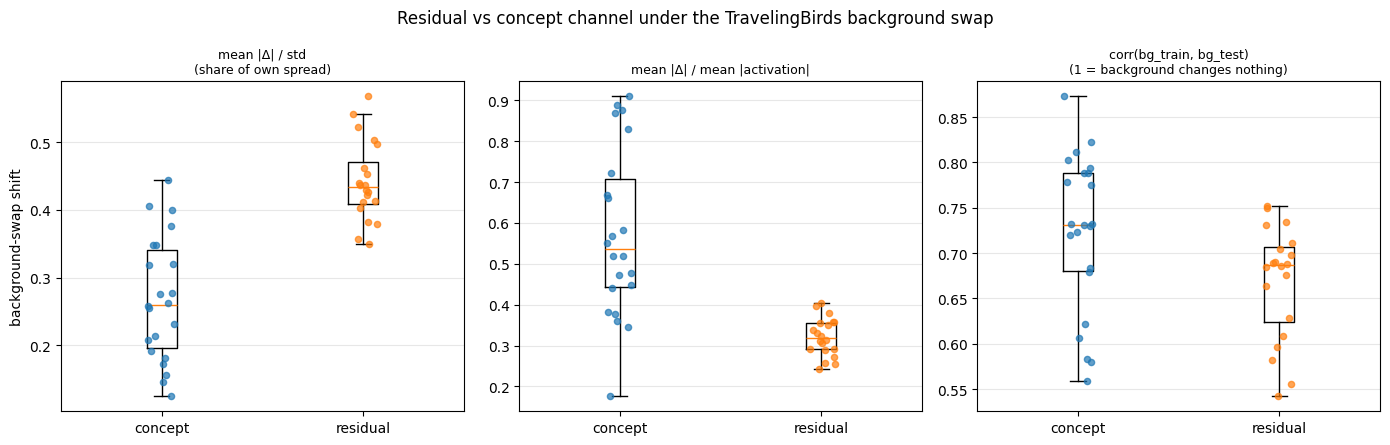

In [169]:
METRICS = [
    "normalized_sensitivity",
    "relative_change",
    "bg_swap_correlation",
]

print(
    shift_df
    .groupby("channel")[METRICS]
    .agg(["mean", "median"])
    .round(3)
)


fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))

labels = [
    "mean |\u0394| / std\n(share of own spread)",
    "mean |\u0394| / mean |activation|",
    "corr(bg_train, bg_test)\n(1 = background changes nothing)",
]

rng = np.random.default_rng(0)

for ax, metric, label in zip(axes, METRICS, labels):

    data = [
        shift_df.loc[shift_df["channel"] == ch, metric].values
        for ch in ("concept", "residual")
    ]

    ax.boxplot(data, showfliers=False)

    for i, vals in enumerate(data, start=1):
        ax.scatter(
            i + rng.uniform(-0.07, 0.07, vals.size),
            vals,
            s=20,
            alpha=0.7,
            zorder=3
        )

    ax.set_xticks([1, 2], ["concept", "residual"])
    ax.set_title(label, fontsize=9)
    ax.grid(axis="y", alpha=0.3)

axes[0].set_ylabel("background-swap shift")

fig.suptitle(
    "Residual vs concept channel under the TravelingBirds background swap"
)
fig.tight_layout()
plt.show()


### Incomplete CUB vs incomplete TravelingBirds concept auroc 

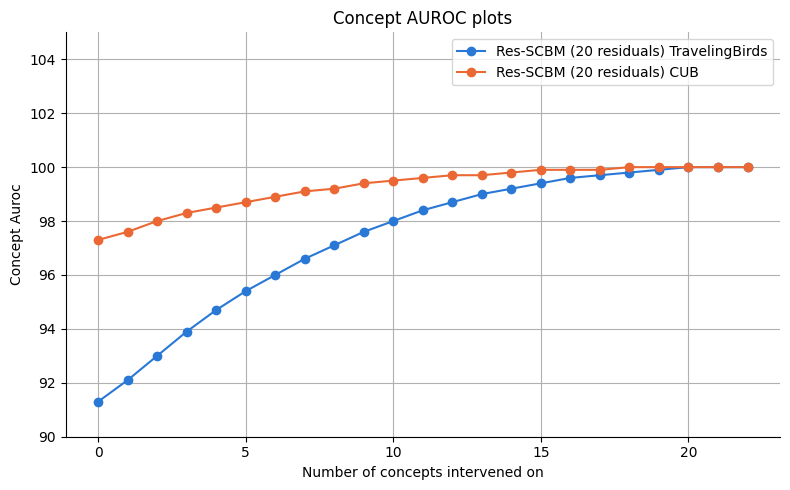

In [170]:


models = [("Res-SCBM (20 residuals) TravelingBirds", "Mateo_025_fixed_residuals_20_2026-08-10_17-06-05_7679e", "scbm_residual", "TravelingBirds"),
          ("Res-SCBM (20 residuals) CUB", "Mateo_025_fixed_residuals_20_2026-08-13_16-06-32_a9023", "scbm_residual", "CUB")]




colors = ["#2a78d6", "#eb6834"]

def plot_concept_auroc(models, colors, title, linear_head_experiment=None):


    fig, ax = plt.subplots(figsize=(8, 5))
    for (label, model_dir, model_type, dataset), color in zip(models, colors):
        concepts_intervened, y_accuracies, c_accuracies, c_auroc = extract_info_from_intervention_log(
            model_dir, model_type=model_type, dataset=dataset, return_c_auroc=True
        )
        ax.plot(concepts_intervened, c_auroc, marker="o", color=color, label=label)


    ax.set_xlabel("Number of concepts intervened on")
    ax.set_ylabel("Concept Auroc")
    ax.set_title(title)
    ax.legend()
    ax.grid(True)
    # y_max = 100
    ax.set_ylim(90, 105)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    plt.tight_layout()
    plt.show()
    
plot_concept_auroc(models, colors, "Concept AUROC plots")



## Complete OOD TravelingBirds experiment

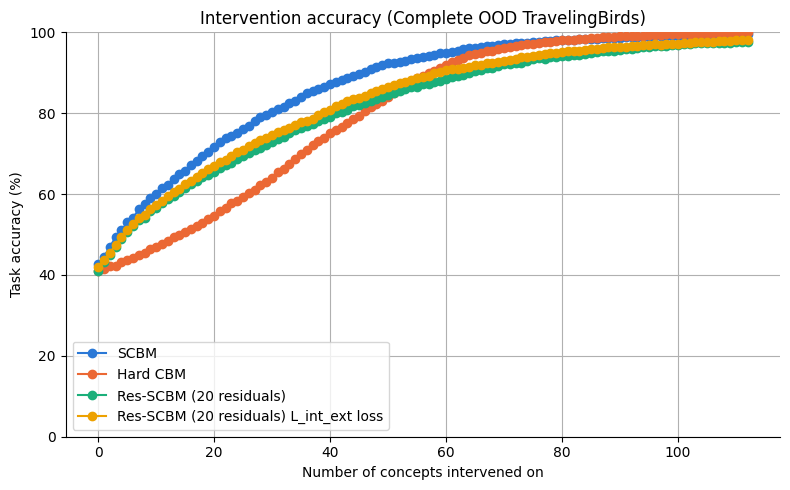

In [171]:
models = [("SCBM", "class_attr_data_10_2026-08-11_18-05-59_ffac3", "scbm"),
          ("Hard CBM", "class_attr_data_10_2026-08-11_18-16-11_ea7f3", "cbm"),
          ("Res-SCBM (20 residuals)", "class_attr_data_10_fixed_residuals_20_2026-08-11_18-05-50_09e4d", "scbm_residual"),
          ("Res-SCBM (20 residuals) L_int_ext loss", "class_attr_data_10_fixed_emp_perc_residuals_20_L_int_extension_loss_weight_1_2026-08-11_18-05-46_b0199", "scbm_residual"),
          #("Res-SCBM (5 residuals) L_int_ext", "Mateo_025_fixed_emp_perc_residuals_5_L_int_extension_loss_weight_1_2026-08-10_17-06-05_57592", "scbm_residual")
          ]

colors = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#9b59b6", "#e74c3c"]


plot(models, colors, "Intervention accuracy (Complete OOD TravelingBirds)")

## Anlaysis of Residual Channel

In [172]:
# Background for training 
category_names = []
category_ids = []

with open(os.path.join("datasets", "TravelingBirds", "categories_places365.txt"), "r") as f:
    for line in f:
        path, category_id = line.strip().rsplit(" ", 1)

        # Remove "/a/", "/b/", etc.
        category_name = path.split("/", 2)[-1]

        category_names.append(category_name)
        category_ids.append(int(category_id))
        
        
print("Category names:", category_names)



Category names: ['airfield', 'airplane_cabin', 'airport_terminal', 'alcove', 'alley', 'amphitheater', 'amusement_arcade', 'amusement_park', 'apartment_building/outdoor', 'aquarium', 'aqueduct', 'arcade', 'arch', 'archaelogical_excavation', 'archive', 'arena/hockey', 'arena/performance', 'arena/rodeo', 'army_base', 'art_gallery', 'art_school', 'art_studio', 'artists_loft', 'assembly_line', 'athletic_field/outdoor', 'atrium/public', 'attic', 'auditorium', 'auto_factory', 'auto_showroom', 'badlands', 'bakery/shop', 'balcony/exterior', 'balcony/interior', 'ball_pit', 'ballroom', 'bamboo_forest', 'bank_vault', 'banquet_hall', 'bar', 'barn', 'barndoor', 'baseball_field', 'basement', 'basketball_court/indoor', 'bathroom', 'bazaar/indoor', 'bazaar/outdoor', 'beach', 'beach_house', 'beauty_salon', 'bedchamber', 'bedroom', 'beer_garden', 'beer_hall', 'berth', 'biology_laboratory', 'boardwalk', 'boat_deck', 'boathouse', 'bookstore', 'booth/indoor', 'botanical_garden', 'bow_window/indoor', 'bowlin

In [173]:
EXPERIMENT_PATH = os.path.join("experiments", "scbm_residual", "TravelingBirds", "Mateo_025_fixed_emp_perc_residuals_20_L_int_extension_loss_weight_1_2026-08-11_12-01-55_9dbed")





### Calculate phi_r per sample

In [174]:
import os
import re
import torch


# ============================================================
# 1. Load and verify the linear prediction head
# ============================================================

checkpoint = torch.load(
    os.path.join(EXPERIMENT_PATH, "model.pth"),
    map_location="cpu",
)

# Support checkpoints saved either directly as a state_dict
# or inside a "state_dict" entry.
if (
    isinstance(checkpoint, dict)
    and "state_dict" in checkpoint
    and isinstance(checkpoint["state_dict"], dict)
):
    scbm_res_model = checkpoint["state_dict"]
else:
    scbm_res_model = checkpoint


# Print all head parameters.
for key, value in scbm_res_model.items():
    if key.startswith("head"):
        print(key, tuple(value.shape))


# Find linear layers in the prediction head.
head_weight_keys = [
    key
    for key in scbm_res_model
    if re.fullmatch(r"head\.\d+\.weight", key)
]

if len(head_weight_keys) == 0:
    raise ValueError("No linear prediction-head weights were found.")


# This analysis assumes that the selected layer directly maps
# [concepts, residuals] to class logits.
head_idx = max(
    int(
        re.fullmatch(
            r"head\.(\d+)\.weight",
            key,
        ).group(1)
    )
    for key in head_weight_keys
)

W = scbm_res_model[
    f"head.{head_idx}.weight"
].detach().float()

b = scbm_res_model[
    f"head.{head_idx}.bias"
].detach().float()

print(
    f"head.{head_idx}: "
    f"W {tuple(W.shape)}, "
    f"b {tuple(b.shape)}"
)


# Bottleneck dimensions.
C = NUM_CONCEPTS = 22
R = NUM_RESIDUALS = W.shape[1] - C

if R <= 0:
    raise ValueError(
        f"Invalid residual dimension R={R}. "
        f"Head input dimension={W.shape[1]}, C={C}."
    )

print(f"Number of concepts: {C}")
print(f"Number of residuals: {R}")


# Split the prediction-head weights.
W_c = W[:, :C]   # [K, C]
W_r = W[:, C:]   # [K, R]

assert W_c.shape[1] == C
assert W_r.shape[1] == R
assert W.shape[1] == C + R


# ============================================================
# 2. Convert prediction logits to class probabilities
# ============================================================

y_pred_logits = torch.load(
    os.path.join(
        EXPERIMENT_PATH,
        "test",
        "y_pred.pt",
    ),
    map_location="cpu",
).float()

y_true = torch.load(
    os.path.join(
        EXPERIMENT_PATH,
        "test",
        "y_true.pt",
    ),
    map_location="cpu",
).long().view(-1)


if y_pred_logits.ndim != 2:
    raise ValueError(
        "Expected y_pred logits to have shape [N, K], "
        f"but received {tuple(y_pred_logits.shape)}."
    )

num_samples, num_classes = y_pred_logits.shape

assert W.shape[0] == num_classes, (
    f"The head has {W.shape[0]} output classes, but "
    f"y_pred has {num_classes} classes."
)

assert y_true.shape[0] == num_samples, (
    "The number of labels does not match the number "
    "of prediction samples."
)


# Convert raw class logits into probabilities.
p_bar = torch.softmax(
    y_pred_logits,
    dim=1,
)

# Aggregated predicted class.
top1_class = y_pred_logits.argmax(dim=1)

assert p_bar.shape == y_pred_logits.shape
assert torch.allclose(
    p_bar.sum(dim=1),
    torch.ones_like(p_bar.sum(dim=1)),
    atol=1e-6,
)

print(
    "y_pred_logits.shape:",
    tuple(y_pred_logits.shape),
)

print(
    "p_bar.shape:",
    tuple(p_bar.shape),
)

print(
    "top1_class.shape:",
    tuple(top1_class.shape),
)


# ============================================================
# 3. Load Rao-Blackwellized MC activation probabilities
# ============================================================

train_probs_path = os.path.join(
    EXPERIMENT_PATH,
    "train",
    "concepts_residuals_pred_probs_mean.pt",
)

test_probs_path = os.path.join(
    EXPERIMENT_PATH,
    "test",
    "concepts_residuals_pred_probs_mean.pt",
)


train_pred_probs_mean = torch.load(
    train_probs_path,
    map_location="cpu",
).float()

test_pred_probs_mean = torch.load(
    test_probs_path,
    map_location="cpu",
).float()


if train_pred_probs_mean.ndim != 2:
    raise ValueError(
        "Expected train activation probabilities to have "
        f"shape [N_train, C + R], but received "
        f"{tuple(train_pred_probs_mean.shape)}."
    )

if test_pred_probs_mean.ndim != 2:
    raise ValueError(
        "Expected test activation probabilities to have "
        f"shape [N_test, C + R], but received "
        f"{tuple(test_pred_probs_mean.shape)}."
    )

assert train_pred_probs_mean.shape[1] == C + R, (
    f"Train activation tensor has "
    f"{train_pred_probs_mean.shape[1]} dimensions, "
    f"but expected {C + R}."
)

assert test_pred_probs_mean.shape[1] == C + R, (
    f"Test activation tensor has "
    f"{test_pred_probs_mean.shape[1]} dimensions, "
    f"but expected {C + R}."
)

assert test_pred_probs_mean.shape[0] == num_samples, (
    "The number of test activation samples does not "
    "match the number of prediction samples."
)


# MC-averaged activation probabilities:
#
#   p_mean[n, j]
#       = (1/M) sum_m sigmoid(eta[n, j, m])
#
train_c_prob_mean = train_pred_probs_mean[:, :C]
train_r_prob_mean = train_pred_probs_mean[:, C:]

test_c_prob_mean = test_pred_probs_mean[:, :C]
test_r_prob_mean = test_pred_probs_mean[:, C:]


print(
    "train_c_prob_mean.shape:",
    tuple(train_c_prob_mean.shape),
)

print(
    "train_r_prob_mean.shape:",
    tuple(train_r_prob_mean.shape),
)

print(
    "test_c_prob_mean.shape:",
    tuple(test_c_prob_mean.shape),
)

print(
    "test_r_prob_mean.shape:",
    tuple(test_r_prob_mean.shape),
)


# ============================================================
# 4. Compute train-set activation baselines
# ============================================================

# Population-average activation probability for each dimension.
c_train_base_rate = train_c_prob_mean.mean(dim=0)
r_train_base_rate = train_r_prob_mean.mean(dim=0)


# Center the test activations using train-set statistics.
centered_c = (
    - c_train_base_rate.unsqueeze(0)
)

centered_r = (
    test_r_prob_mean
    - r_train_base_rate.unsqueeze(0)
)


assert centered_c.shape == (num_samples, C)
assert centered_r.shape == (num_samples, R)

print(
    "centered_c.shape:",
    tuple(centered_c.shape),
)

print(
    "centered_r.shape:",
    tuple(centered_r.shape),
)


# ============================================================
# 5. Compute probability-weighted class contrasts
# ============================================================

# Weight vectors for the predicted class:
#
#   W_top1[n, :]
#       = W[k*_n, :]
#
W_c_top1 = W_c[top1_class]  # [N, C]
W_r_top1 = W_r[top1_class]  # [N, R]


# Probability-weighted average class weights:
#
#   E_p[W_c][n, i]
#       = sum_k p_bar[n, k] W_c[k, i]
#
#   E_p[W_r][n, j]
#       = sum_k p_bar[n, k] W_r[k, j]
#
expected_W_c = p_bar @ W_c  # [N, C]
expected_W_r = p_bar @ W_r  # [N, R]


# Probability-weighted class contrasts:
#
#   u_c[n, i]
#       = W_c[k*_n, i] - sum_k p[n, k] W_c[k, i]
#
#   u_r[n, j]
#       = W_r[k*_n, j] - sum_k p[n, k] W_r[k, j]
#
u_c = W_c_top1 - expected_W_c
u_r = W_r_top1 - expected_W_r


assert u_c.shape == centered_c.shape
assert u_r.shape == centered_r.shape

print(
    "u_c.shape:",
    tuple(u_c.shape),
)

print(
    "u_r.shape:",
    tuple(u_r.shape),
)


# ============================================================
# 6. Per-sample, per-dimension centered contributions
# ============================================================

# Concept contribution:
#
#   phi_c[n, i]
#       = u_c[n, i]
#         * (c_mean[n, i] - c_train_base[i])
#
phi_c = u_c * centered_c


# Residual contribution:
#
#   phi_r[n, j]
#       = u_r[n, j]
#         * (r_mean[n, j] - r_train_base[j])
#
phi_r = u_r * centered_r

abs_phi_r = phi_r.abs()

# ============================================================
# Per-sample residual contribution shares
# ============================================================

# For each sample, normalize residual contributions so that
# they sum to 1 across residual dimensions.
residual_contribution_share = (
    abs_phi_r
    / abs_phi_r.sum(dim=1, keepdim=True).clamp_min(1e-12)
)

assert residual_contribution_share.shape == (num_samples, R)

print(
    "residual_contribution_share.shape:",
    tuple(residual_contribution_share.shape),
)

print(
    "Mean row sum:",
    residual_contribution_share.sum(dim=1).mean().item(),
)









assert phi_c.shape == (num_samples, C)
assert phi_r.shape == (num_samples, R)

print(
    "phi_c.shape:",
    tuple(phi_c.shape),
)

print(
    "phi_r.shape:",
    tuple(phi_r.shape),
)


# ============================================================
# 7. Most important residuals for each sample
# ============================================================

num_top_residuals = min(5, R)

top_residuals = torch.topk(
    abs_phi_r,
    k=num_top_residuals,
    dim=1,
)

top_residual_indices = top_residuals.indices
top_residual_abs_contributions = top_residuals.values


# Signed contribution for each selected residual.
top_residual_signed_contributions = torch.gather(
    phi_r,
    dim=1,
    index=top_residual_indices,
)


# Activation deviation for each selected residual.
top_residual_activation_deviations = torch.gather(
    centered_r,
    dim=1,
    index=top_residual_indices,
)


# Probability-weighted class contrast for each selected residual.
top_residual_weighted_contrasts = torch.gather(
    u_r,
    dim=1,
    index=top_residual_indices,
)


sample_idx = 1

print(f"\nExample: test sample {sample_idx}")
print(
    "True class:",
    y_true[sample_idx].item(),
)
print(
    "Predicted class:",
    top1_class[sample_idx].item(),
)
print(
    "Predicted probability:",
    p_bar[
        sample_idx,
        top1_class[sample_idx],
    ].item(),
)


for rank in range(num_top_residuals):
    residual_idx = top_residual_indices[
        sample_idx,
        rank,
    ].item()

    contribution = top_residual_signed_contributions[
        sample_idx,
        rank,
    ].item()

    absolute_contribution = top_residual_abs_contributions[
        sample_idx,
        rank,
    ].item()

    weighted_contrast = top_residual_weighted_contrasts[
        sample_idx,
        rank,
    ].item()

    activation_deviation = top_residual_activation_deviations[
        sample_idx,
        rank,
    ].item()

    print(
        f"Rank {rank + 1}: "
        f"residual {residual_idx} | "
        f"contribution={contribution:.6f} | "
        f"|contribution|={absolute_contribution:.6f} | "
        f"weighted contrast={weighted_contrast:.6f} | "
        f"activation deviation={activation_deviation:.6f}"
    )

head.0.weight (200, 42)
head.0.bias (200,)
head.0: W (200, 42), b (200,)
Number of concepts: 22
Number of residuals: 20
y_pred_logits.shape: (5794, 200)
p_bar.shape: (5794, 200)
top1_class.shape: (5794,)
train_c_prob_mean.shape: (4796, 22)
train_r_prob_mean.shape: (4796, 20)
test_c_prob_mean.shape: (5794, 22)
test_r_prob_mean.shape: (5794, 20)


AssertionError: 

### Calcalate per class metrics

In [ ]:
# ============================================================
# 8. Per-class residual contribution
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
import torch


# Ensure labels have shape [N] and are on the same device as phi_r.
y_true = y_true.to(phi_r.device).long().view(-1)

num_samples = phi_r.shape[0]
num_classes = W.shape[0]

assert y_true.shape[0] == num_samples, (
    f"y_true contains {y_true.shape[0]} samples, "
    f"but phi_r contains {num_samples}."
)

assert top1_class.shape[0] == num_samples

assert phi_r.shape == (num_samples, R), (
    f"Expected phi_r shape {(num_samples, R)}, "
    f"but received {tuple(phi_r.shape)}."
)

assert centered_r.shape == (num_samples, R)
assert residual_contribution_share.shape == (num_samples, R)

assert y_true.min() >= 0
assert y_true.max() < num_classes


# ------------------------------------------------------------
# A. Per-class statistics using true-class membership
# ------------------------------------------------------------

# Main importance measure:
#
# I[c, j] = mean_{n: y_n = c} |phi_r[n, j]|
per_class_mean_abs_contribution = torch.full(
    (num_classes, R),
    float("nan"),
    dtype=phi_r.dtype,
    device=phi_r.device,
)

# Scale-free companion to the measure above:
#
# S[c, j] = mean_{n: y_n = c} residual_contribution_share[n, j]
#         = mean_{n: y_n = c} |phi_r[n, j]| / sum_j' |phi_r[n, j']|
#
# Each sample contributes equally regardless of how large its
# total residual contribution is, so this reports how the
# residual channel is *allocated* within the class rather than
# how much residual signal the class carries in absolute terms.
per_class_mean_contribution_share = torch.full(
    (num_classes, R),
    float("nan"),
    dtype=residual_contribution_share.dtype,
    device=residual_contribution_share.device,
)

# Spread of that share across the samples of the class:
#
# std_{n: y_n = c} residual_contribution_share[n, j]
#
# A small std means the class allocates its residual channel the
# same way for every member; a large std means the mean share is
# an average over samples that disagree.
per_class_std_contribution_share = torch.full(
    (num_classes, R),
    float("nan"),
    dtype=residual_contribution_share.dtype,
    device=residual_contribution_share.device,
)

# Mean signed contribution:
#
# mean_{n: y_n = c} phi_r[n, j]
per_class_mean_signed_contribution = torch.full(
    (num_classes, R),
    float("nan"),
    dtype=phi_r.dtype,
    device=phi_r.device,
)

# Mean magnitude of the centered activation:
#
# mean_{n: y_n = c} |r_bar[n, j] - r_train_base[j]|
per_class_mean_abs_activation_deviation = torch.full(
    (num_classes, R),
    float("nan"),
    dtype=centered_r.dtype,
    device=centered_r.device,
)

# Mean signed centered activation:
#
# mean_{n: y_n = c} (r_bar[n, j] - r_train_base[j])
per_class_mean_activation_deviation = torch.full(
    (num_classes, R),
    float("nan"),
    dtype=centered_r.dtype,
    device=centered_r.device,
)

num_samples_per_class = torch.zeros(
    num_classes,
    dtype=torch.long,
    device=phi_r.device,
)


for class_idx in range(num_classes):
    class_mask = y_true == class_idx
    class_count = int(class_mask.sum().item())

    num_samples_per_class[class_idx] = class_count

    if class_count == 0:
        continue

    class_phi_r = phi_r[class_mask]          # [N_c, R]
    class_share = residual_contribution_share[class_mask]  # [N_c, R]
    # centered_r = r_bar - r_train_base = r_bar - mean(r_bar) for train set where r_bar = r_pred_probs_mean
    class_centered_r = centered_r[class_mask]  # [N_c, R]

    per_class_mean_abs_contribution[class_idx] = (
        class_phi_r.abs().mean(dim=0)
    )

    per_class_mean_contribution_share[class_idx] = (
        class_share.mean(dim=0)
    )

    # Population standard deviation across the samples of the
    # class. correction=0 also works when the class has one
    # sample, matching the convention used for the rank spreads.
    per_class_std_contribution_share[class_idx] = (
        class_share.std(
            dim=0,
            correction=0,
        )
    )

    per_class_mean_signed_contribution[class_idx] = (
        class_phi_r.mean(dim=0)
    )

    per_class_mean_abs_activation_deviation[class_idx] = (
        class_centered_r.abs().mean(dim=0)
    )

    per_class_mean_activation_deviation[class_idx] = (
        class_centered_r.mean(dim=0)
    )


print(
    "per_class_mean_abs_contribution.shape:",
    tuple(per_class_mean_abs_contribution.shape),
)

print(
    "per_class_mean_contribution_share.shape:",
    tuple(per_class_mean_contribution_share.shape),
)

print(
    "per_class_std_contribution_share.shape:",
    tuple(per_class_std_contribution_share.shape),
)

print(
    "Number of samples per class:",
    num_samples_per_class.detach().cpu().tolist(),
)


In [ ]:
# ============================================================
# Get mean and std rank of residual importance per class
# ============================================================

import numpy as np
import torch
from scipy.stats import rankdata


# Ensure labels are one-dimensional and on the same device.
y_true = y_true.to(phi_r.device).long().view(-1)

num_samples, num_residuals = phi_r.shape
num_classes = W.shape[0]

assert num_residuals == R, (
    f"phi_r has {num_residuals} residual dimensions, "
    f"but R={R}."
)

assert y_true.shape[0] == num_samples, (
    f"y_true has {y_true.shape[0]} samples, "
    f"but phi_r has {num_samples}."
)

assert top1_class.shape[0] == num_samples

assert y_true.min().item() >= 0
assert y_true.max().item() < num_classes


# ------------------------------------------------------------
# 1. Rank residuals for every sample
# ------------------------------------------------------------

# Rank according to absolute contribution:
#
# rank 1 = largest absolute contribution
# rank R = smallest absolute contribution
abs_phi_r = phi_r.abs()  # [N, R]


# Use average ranks for ties.
#
# Example:
# contributions = [0.8, 0.4, 0.4, 0.1]
# ranks         = [1.0, 2.5, 2.5, 4.0]
#
# The negative sign is used because scipy.rankdata assigns
# rank 1 to the smallest value by default.
abs_phi_r_np = abs_phi_r.detach().cpu().numpy()

per_sample_residual_ranks_np = np.apply_along_axis(
    lambda row: rankdata(
        -row,
        method="average",
    ),
    axis=1,
    arr=abs_phi_r_np,
)

per_sample_residual_ranks = torch.from_numpy(
    per_sample_residual_ranks_np
).to(
    device=phi_r.device,
    dtype=phi_r.dtype,
)


assert per_sample_residual_ranks.shape == (num_samples, R)

print(
    "per_sample_residual_ranks.shape:",
    tuple(per_sample_residual_ranks.shape),
)


# ============================================================
# 2. Aggregate ranks within each true class
# ============================================================

per_class_mean_rank = torch.full(
    (num_classes, R),
    float("nan"),
    dtype=phi_r.dtype,
    device=phi_r.device,
)

per_class_std_rank = torch.full(
    (num_classes, R),
    float("nan"),
    dtype=phi_r.dtype,
    device=phi_r.device,
)

per_class_median_rank = torch.full(
    (num_classes, R),
    float("nan"),
    dtype=phi_r.dtype,
    device=phi_r.device,
)

num_samples_per_class = torch.zeros(
    num_classes,
    dtype=torch.long,
    device=phi_r.device,
)


for class_idx in range(num_classes):
    class_mask = y_true == class_idx
    class_count = int(class_mask.sum().item())

    num_samples_per_class[class_idx] = class_count

    if class_count == 0:
        continue

    # Shape: [number of class samples, R]
    class_ranks = per_sample_residual_ranks[class_mask]

    per_class_mean_rank[class_idx] = (
        class_ranks.mean(dim=0)
    )

    # Population standard deviation across samples in the class.
    # correction=0 also works when the class has one sample.
    per_class_std_rank[class_idx] = (
        class_ranks.std(
            dim=0,
            correction=0,
        )
    )

    per_class_median_rank[class_idx] = (
        class_ranks.median(dim=0).values
    )


print(
    "per_class_mean_rank.shape:",
    tuple(per_class_mean_rank.shape),
)

print(
    "per_class_std_rank.shape:",
    tuple(per_class_std_rank.shape),
)

print(
    "per_class_median_rank.shape:",
    tuple(per_class_median_rank.shape),
)


# ============================================================
# 3. Inspect one class
# ============================================================

class_to_inspect = 1
num_to_show = min(10, R)

if not 0 <= class_to_inspect < num_classes:
    raise ValueError(
        f"class_to_inspect must be between 0 and "
        f"{num_classes - 1}, but received {class_to_inspect}."
    )

class_count = int(
    num_samples_per_class[class_to_inspect].item()
)

if class_count == 0:
    raise ValueError(
        f"Class {class_to_inspect} has no samples."
    )


# Lower mean rank means more consistently important.
residual_order = torch.argsort(
    per_class_mean_rank[class_to_inspect],
    descending=False,
)


print(
    f"\nResidual importance ranks for class "
    f"{class_to_inspect} "
    f"(n={class_count}):"
)


for position, residual_idx in enumerate(
    residual_order[:num_to_show],
    start=1,
):
    j = int(residual_idx.item())

    mean_rank = per_class_mean_rank[
        class_to_inspect,
        j,
    ].item()

    std_rank = per_class_std_rank[
        class_to_inspect,
        j,
    ].item()

    median_rank = per_class_median_rank[
        class_to_inspect,
        j,
    ].item()

    mean_abs_contribution = (
        per_class_mean_abs_contribution[
            class_to_inspect,
            j,
        ].item()
    )

    mean_contribution_share = (
        per_class_mean_contribution_share[
            class_to_inspect,
            j,
        ].item()
    )

    std_contribution_share = (
        per_class_std_contribution_share[
            class_to_inspect,
            j,
        ].item()
    )

    print(
        f"{position:2d}. residual {j:2d} | "
        f"mean rank = {mean_rank:.2f} | "
        f"std rank = {std_rank:.2f} | "
        f"median rank = {median_rank:.2f} | "
        f"mean |contribution| = "
        f"{mean_abs_contribution:.6f} | "
        f"mean share = "
        f"{mean_contribution_share:.4f} | "
        f"std share = "
        f"{std_contribution_share:.4f}"
    )

In [ ]:
### Get class_names ###
with open(os.path.join("datasets", "CUB", "CUB_200_2011", "CUB_200_2011", "classes.txt"), "r") as f:
    class_names_names = [line.strip().split(" ")[1] for line in f.readlines()]




# ============================================================
# DataFrame with all ranked residuals for every class
# ============================================================

import os
import pandas as pd
import torch


num_to_show = NUM_RESIDUALS

rows = []

for class_idx in range(num_classes):
    class_count = int(
        num_samples_per_class[class_idx].item()
    )

    # Keep the class in the output even if it has no samples.
    if class_count == 0:
        for position in range(1, num_to_show + 1):
            rows.append(
                {
                    "class_idx": class_idx,
                    "class_name": class_names_names[class_idx],
                    "num_samples": 0,
                    "residual_position": position,
                    "residual_idx": pd.NA,
                    "mean_rank": float("nan"),
                    "std_rank": float("nan"),
                    "median_rank": float("nan"),
                    "mean_abs_contribution": float("nan"),
                    "mean_per_sample_share": float("nan"),
                    "std_per_sample_share": float("nan"),
                }
            )
        continue

    # Lower mean rank means more consistently important.
    residual_order = torch.argsort(
        per_class_mean_rank[class_idx],
        descending=False,
    )

    top_residual_indices = residual_order[:num_to_show]

    for position, residual_idx in enumerate(
        top_residual_indices,
        start=1,
    ):
        j = int(residual_idx.item())

        rows.append(
            {
                "class_idx": class_idx,
                "class_name": class_names_names[class_idx],
                "num_samples": class_count,
                "residual_position": position,
                "residual_idx": j,
                "mean_rank": per_class_mean_rank[
                    class_idx, j
                ].item(),
                "std_rank": per_class_std_rank[
                    class_idx, j
                ].item(),
                "median_rank": per_class_median_rank[
                    class_idx, j
                ].item(),
                "mean_abs_contribution": (
                    per_class_mean_abs_contribution[
                        class_idx, j
                    ].item()
                ),
                "mean_per_sample_share": (
                    per_class_mean_contribution_share[
                        class_idx, j
                    ].item()
                ),
                "std_per_sample_share": (
                    per_class_std_contribution_share[
                        class_idx, j
                    ].item()
                ),
            }
        )


all_residuals_per_class_df = pd.DataFrame(rows)

# Make nullable integer columns.
all_residuals_per_class_df["class_idx"] = (
    all_residuals_per_class_df["class_idx"]
    .astype("Int64")
)

all_residuals_per_class_df["residual_position"] = (
    all_residuals_per_class_df["residual_position"]
    .astype("Int64")
)

all_residuals_per_class_df["residual_idx"] = (
    all_residuals_per_class_df["residual_idx"]
    .astype("Int64")
)

print(
    "DataFrame shape:",
    all_residuals_per_class_df.shape,
)


all_residuals_per_class_df.to_csv("TravelingBirds_analysis/all_residuals_per_class.csv", index=False)


display(all_residuals_per_class_df.head(70))


